# Advanced Autolyse Features

This notebook demonstrates the advanced features added to Autolyse v2:
- **Granular Control Flags**: Enable/disable specific analyses
- **Feature Engineering**: Automatic polynomial, interaction, and ratio features
- **Random Seeding**: Reproducible analysis with fixed random_seed
- **Batch Sampling**: Fast iteration on large datasets
- **Advanced Insights**: Multivariate pattern detection (3+ features)

## Setup

In [1]:
import pandas as pd
import numpy as np
import os
from autolyse import Autolyse

# Set your API key if you have one, otherwise set to None
GEMINI_KEY = os.environ.get("GEMINI_KEY", None)

# Create sample datasets for demonstration
np.random.seed(42)

# Scenario 1: E-commerce dataset
ecommerce_df = pd.DataFrame({
    'customer_id': range(1, 501),
    'age': np.random.randint(18, 70, 500),
    'purchase_count': np.random.randint(0, 50, 500),
    'avg_order_value': np.random.gamma(100, 2, 500),
    'customer_lifetime_value': np.random.gamma(5000, 2, 500),
    'days_since_purchase': np.random.randint(0, 365, 500),
    'region': np.random.choice(['North', 'South', 'East', 'West'], 500),
    'device_type': np.random.choice(['Mobile', 'Desktop', 'Tablet'], 500),
})

print(f"E-commerce dataset shape: {ecommerce_df.shape}")
ecommerce_df.head()

E-commerce dataset shape: (500, 8)


,customer_id,age,purchase_count,avg_order_value,customer_lifetime_value,days_since_purchase,region,device_type
0,1,56,15,199.174189,10095.510049,53,North,Mobile
1,2,69,38,230.367051,9930.493124,325,North,Mobile
2,3,46,4,231.317824,10307.525787,356,South,Desktop
3,4,32,21,210.288333,9913.919524,312,North,Desktop
4,5,60,28,182.356337,10184.553213,137,East,Mobile


## Example 1: Granular Control - Custom Analysis Selection

Use individual flags to run only the analyses you need.


=== Example 1: Custom Analysis Selection ===
Running only: Statistics + Correlations + Visualizations
Skipping: Distributions, Outliers, Relationships, Advanced Insights

Starting Autolyse Analysis...
Dataset: 500 rows × 8 columns

1️⃣  Analyzing data structure and types...
2️⃣  Running analyzers (2 enabled)...
3️⃣  Generating visualizations (matplotlib + plotly)...
4️⃣  Generating AI insights...
⚠️  Warning: Could not generate some AI insights: 'missing_values'
5️⃣  Preparing output...


# Automated EDA Analysis - Autolyse

## Dataset Summary


**Dataset Shape:** 500 rows × 8 columns

**Column Information:**
- Numeric Columns: 6
- Categorical Columns: 2
- Date Columns: 0
- Missing Values: 0
        

## Column Information

...

## AI Insights

### Statistics

> The 'customer_id' column shows a approximately symmetric distribution with moderate to high variability. This indicates a relatively normal pattern in the data with 0.0% missing values.
The 'age' column shows a approximately symmetric distribution with moderate to high variability. This indicates a relatively normal pattern in the data with 0.0% missing values.
The 'purchase_count' column shows a approximately symmetric distribution with moderate to high variability. This indicates a relatively normal pattern in the data with 0.0% missing values.

## Visualizations

### Correlation Heatmap

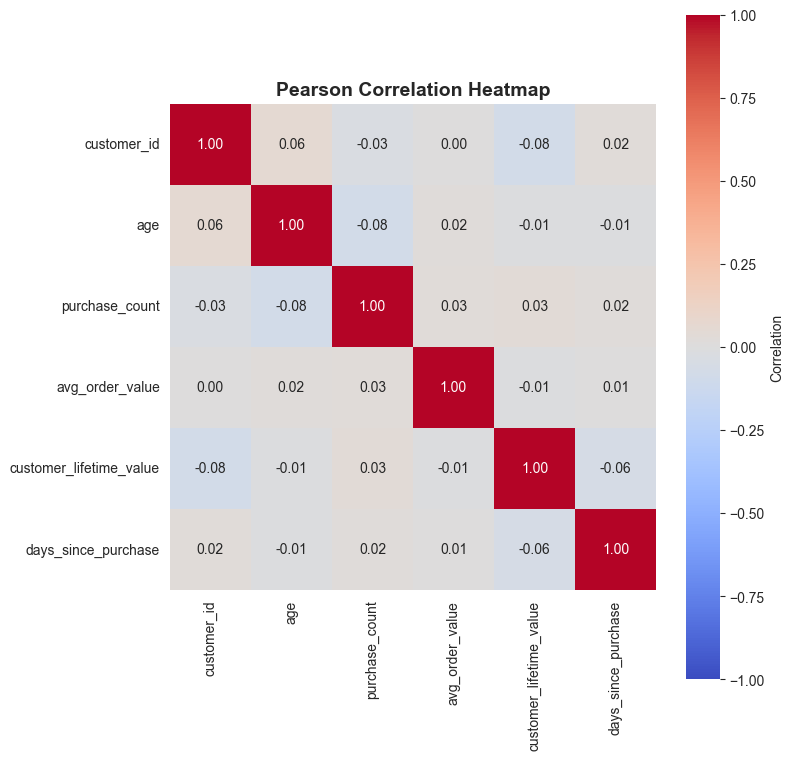

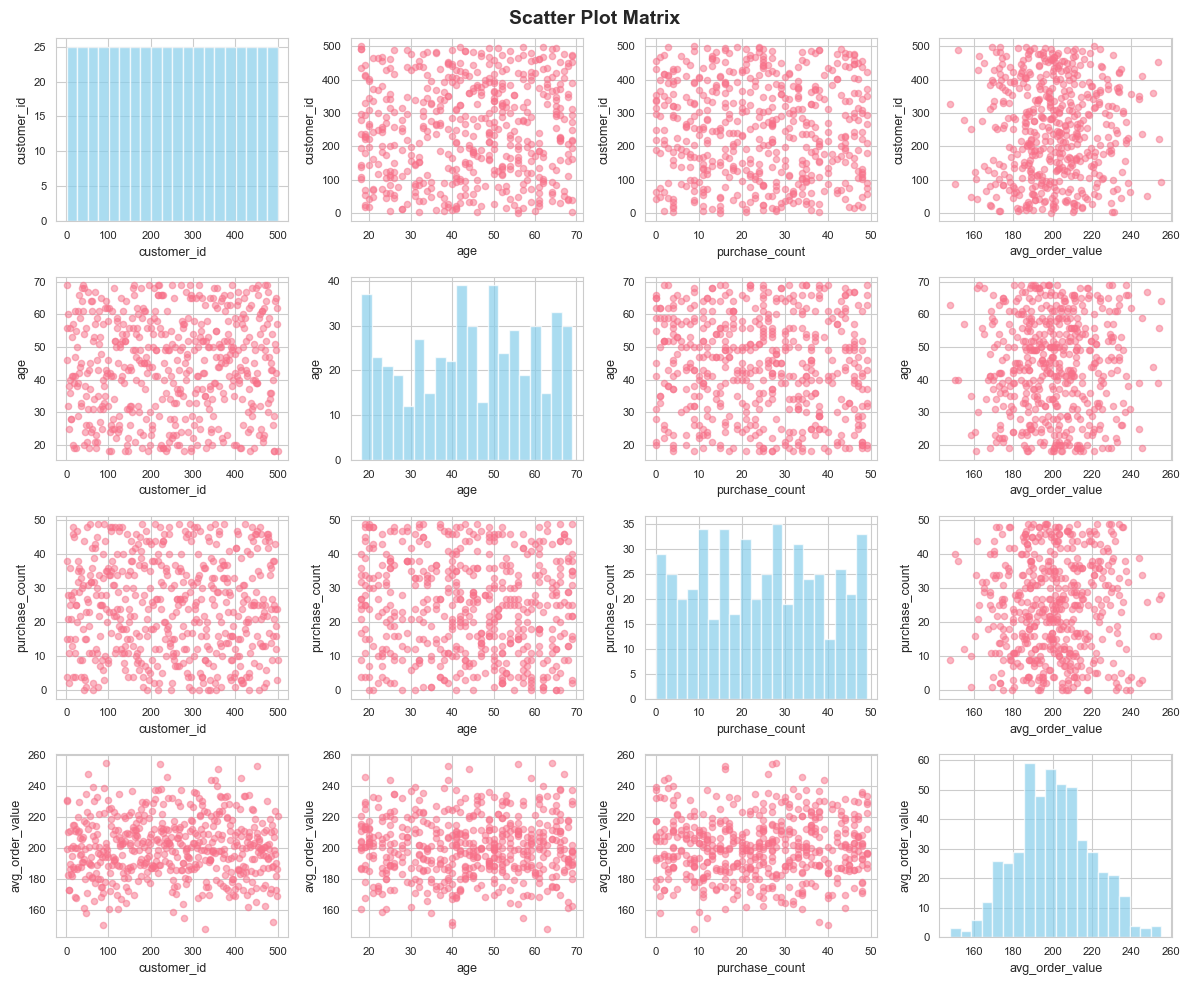

In [2]:
# Example: Run only statistics and correlations (skip distributions, outliers, etc.)
print("\n=== Example 1: Custom Analysis Selection ===")
print("Running only: Statistics + Correlations + Visualizations")
print("Skipping: Distributions, Outliers, Relationships, Advanced Insights\n")

autolyse_custom = Autolyse(
    html=False,  # Display in Jupyter instead of HTML
    api_key=GEMINI_KEY,
    # Enable only specific analyses
    enable_statistics=True,      # ✓ Run statistics
    enable_correlations=True,     # ✓ Run correlations
    enable_visualizations=True,   # ✓ Generate charts
    enable_missing_values=False,  # ✗ Skip missing values
    enable_distributions=False,   # ✗ Skip distributions
    enable_outliers=False,        # ✗ Skip outlier detection
    enable_relationships=False,   # ✗ Skip relationships
    enable_advanced_insights=False # ✗ Skip advanced analysis
)

results = autolyse_custom.analyse(ecommerce_df, show_progress=True)

In [3]:
# Check what analyses were run
print("\nAnalyses executed:")
for analysis_name in results.keys():
    print(f"  ✓ {analysis_name}")

# Access specific results
stats = autolyse_custom.get_analysis_results().get('statistics', {})
print(f"\nStatistics for first numeric column: {list(stats.keys())[0]}")
first_col_stats = stats[list(stats.keys())[0]]
print(f"  Mean: {first_col_stats.get('mean', 'N/A'):.2f}")
print(f"  Std: {first_col_stats.get('std', 'N/A'):.2f}")


Analyses executed:
  ✓ statistics
  ✓ correlations

Statistics for first numeric column: customer_id
  Mean: 250.50
  Std: 144.48


## Example 2: Feature Engineering - Automatic Feature Creation

Enable automatic feature engineering to create polynomial, interaction, and ratio features.


=== Example 2: Feature Engineering ===
Creating polynomial, interaction, and ratio features automatically...

Starting Autolyse Analysis...
Dataset: 500 rows × 8 columns

1️⃣  Analyzing data structure and types...
1️⃣.5️⃣  Engineering new features...
  ⚠️  Feature engineering skipped: 'int' object is not iterable
2️⃣  Running analyzers (7 enabled)...
3️⃣  Generating visualizations (matplotlib + plotly)...
4️⃣  Generating AI insights...
5️⃣  Preparing output...


# Automated EDA Analysis - Autolyse

## Dataset Summary


**Dataset Shape:** 500 rows × 8 columns

**Column Information:**
- Numeric Columns: 6
- Categorical Columns: 2
- Date Columns: 0
- Missing Values: 0
        

## Column Information

...

## Visualizations

### Distributions

### Missing Values

### Correlation Heatmap

### Boxplots

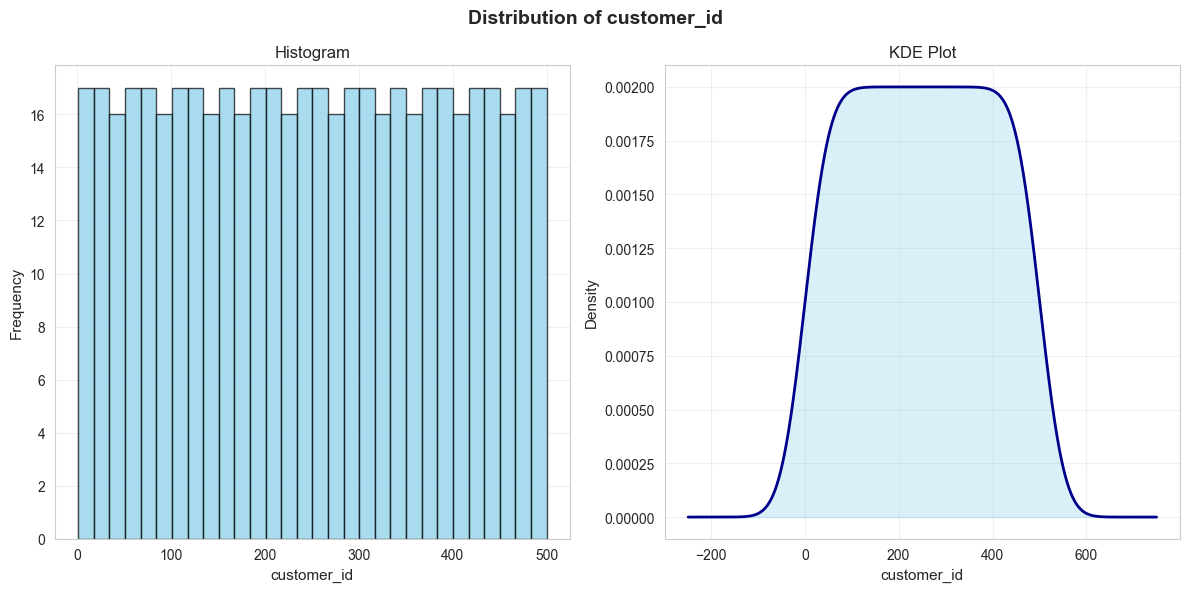

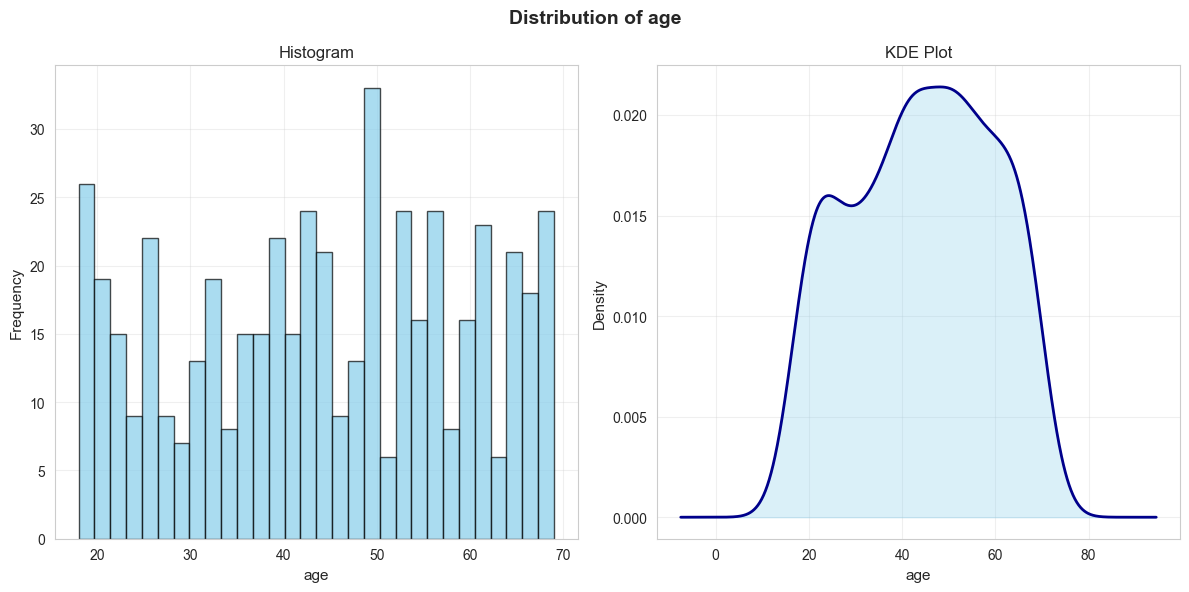

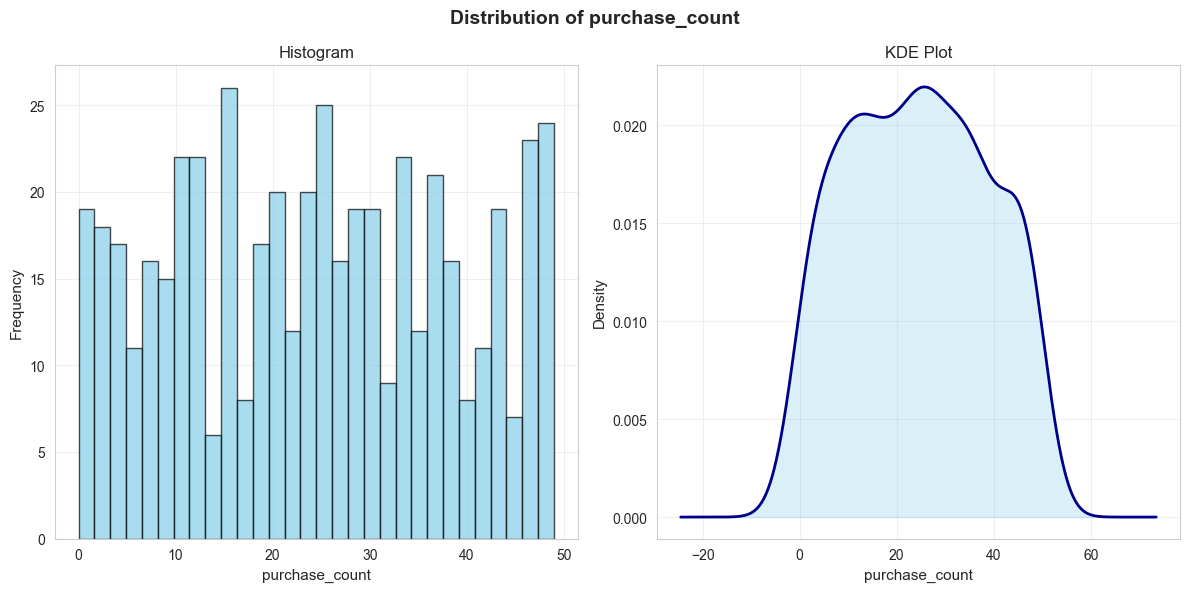

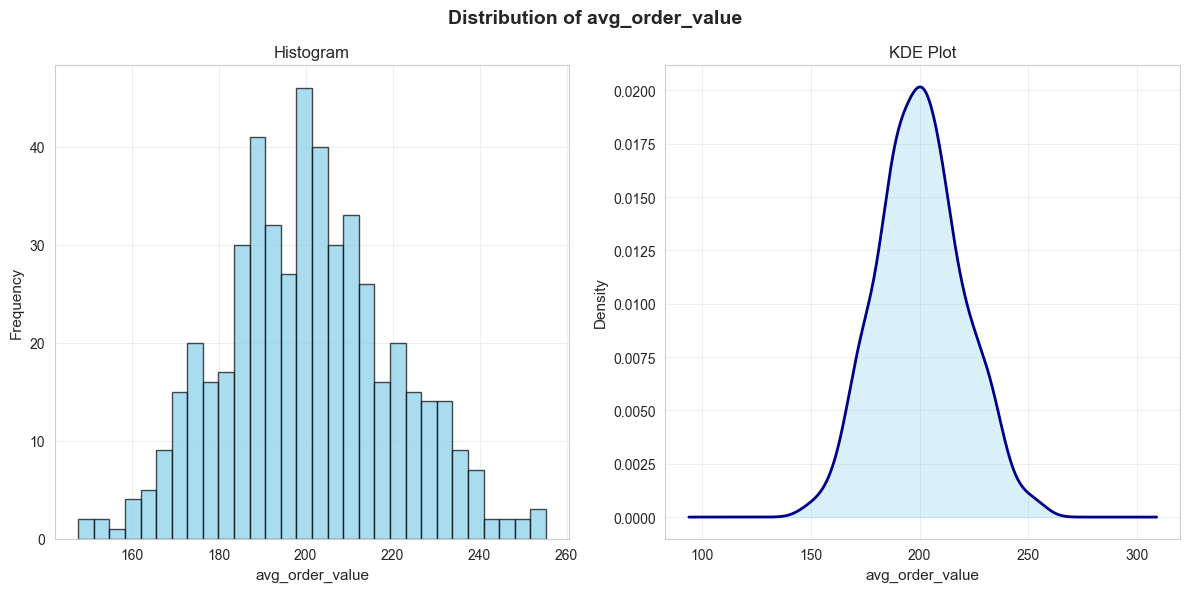

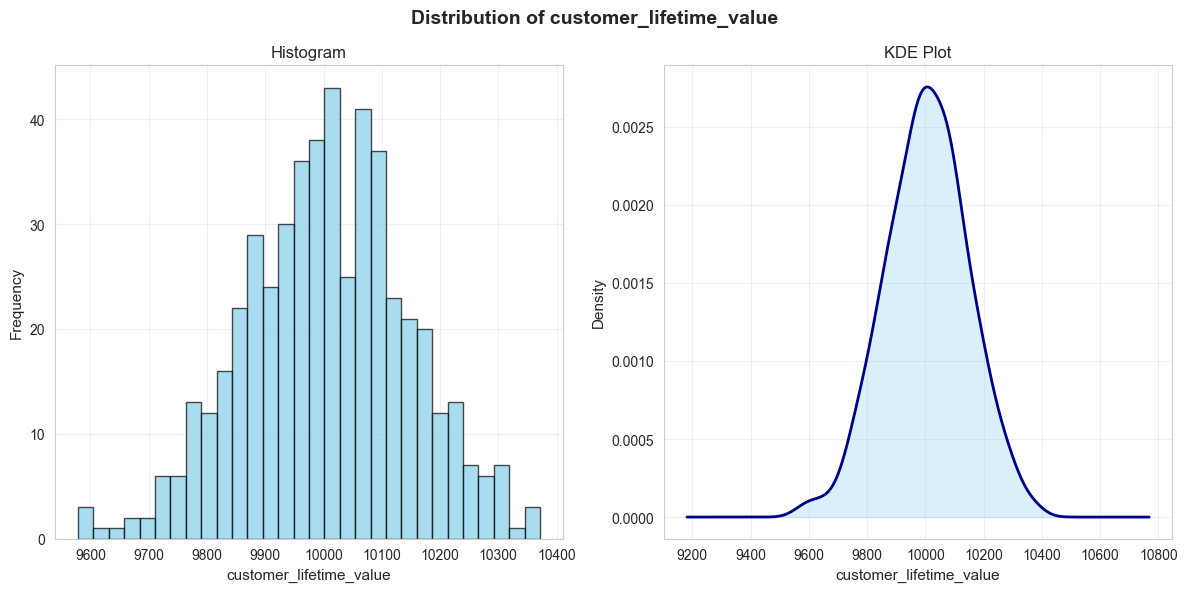

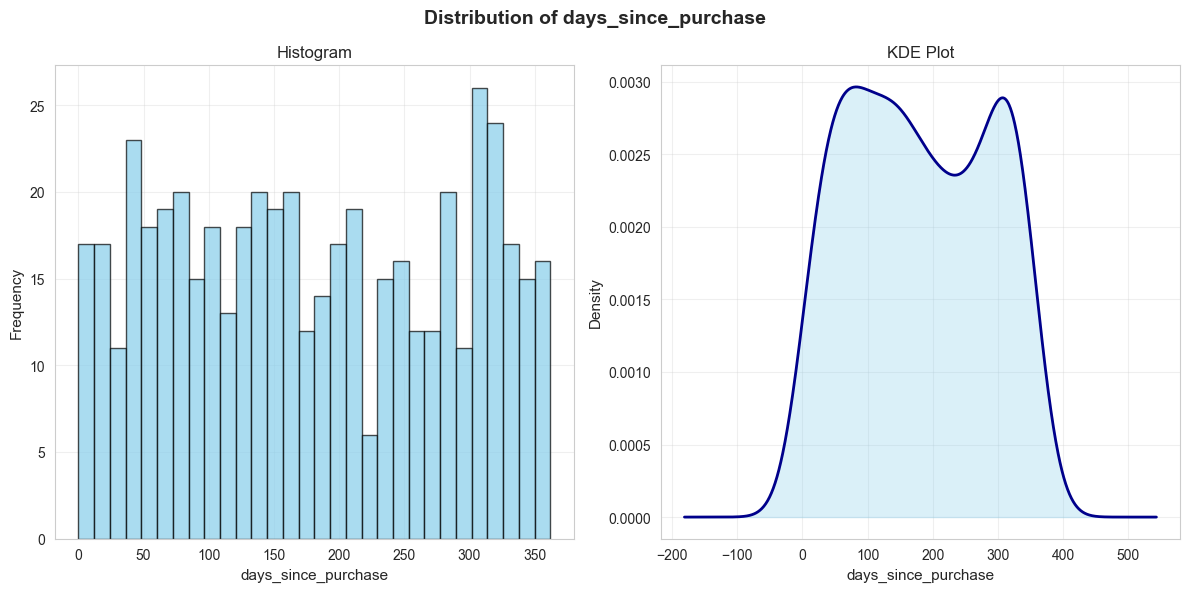

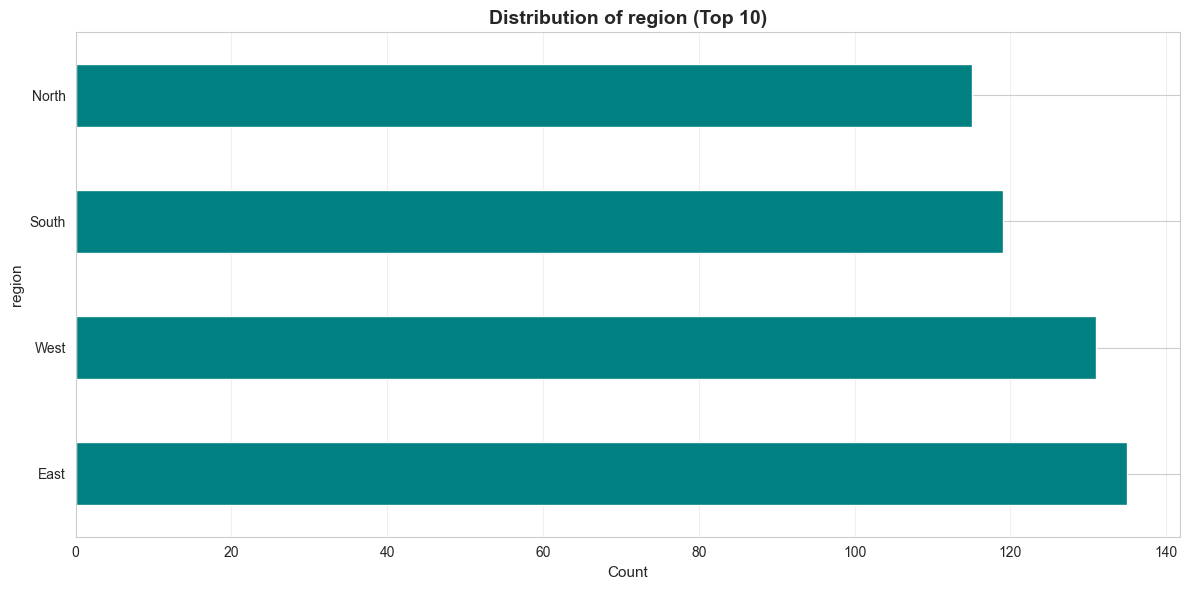

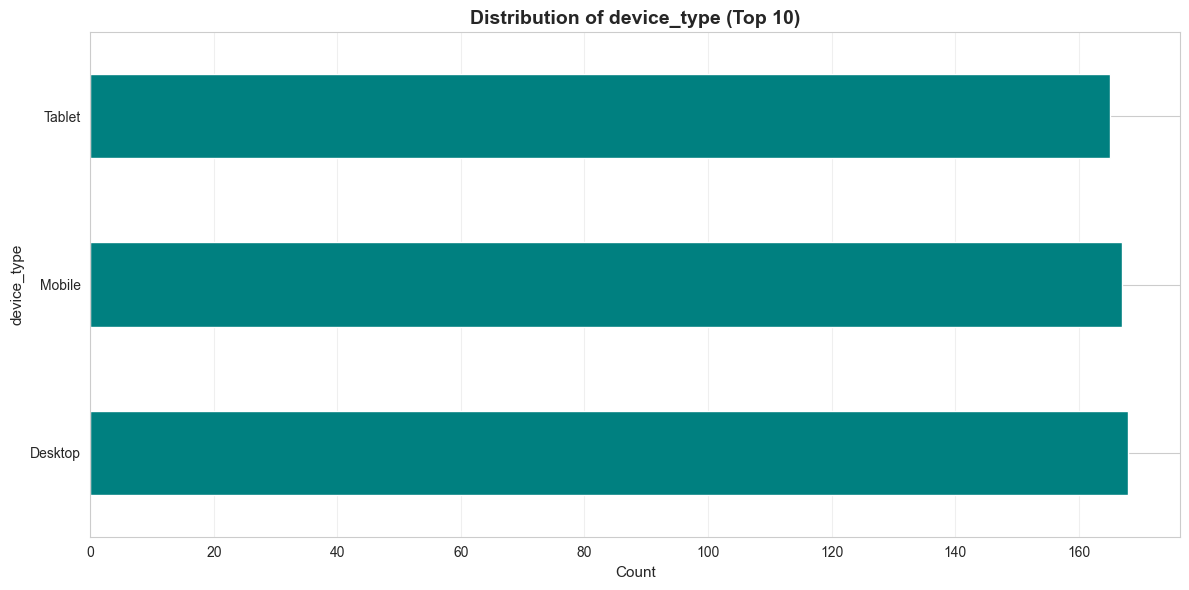

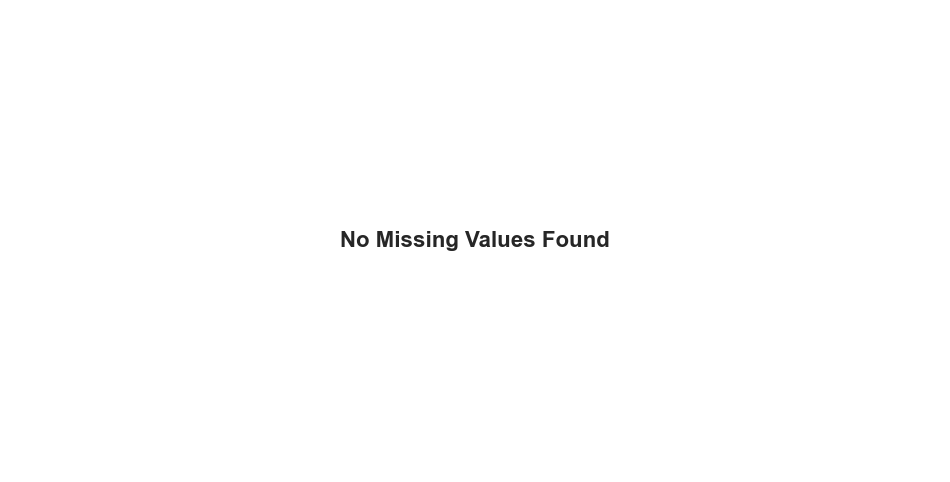

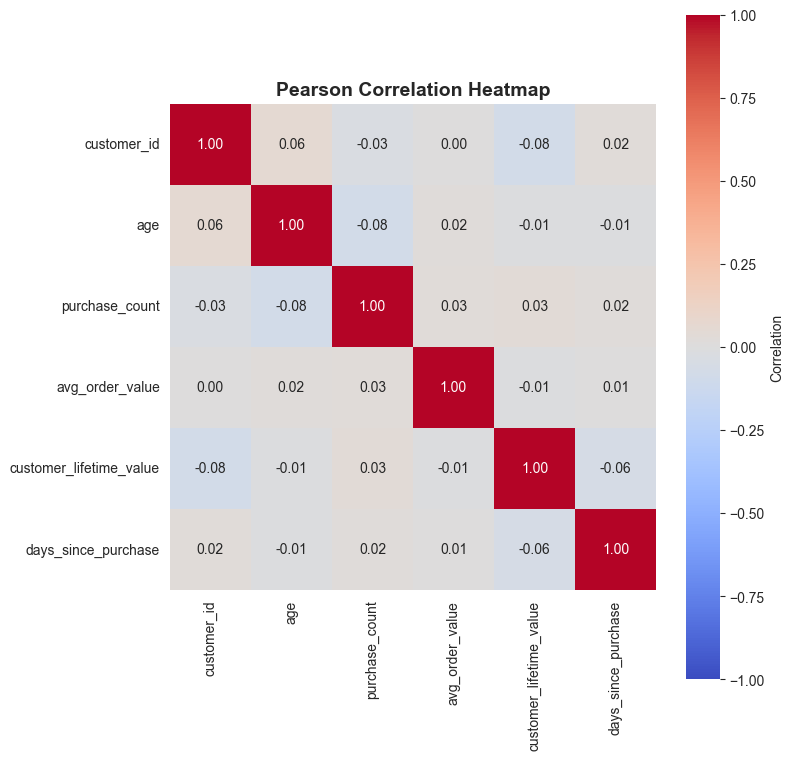

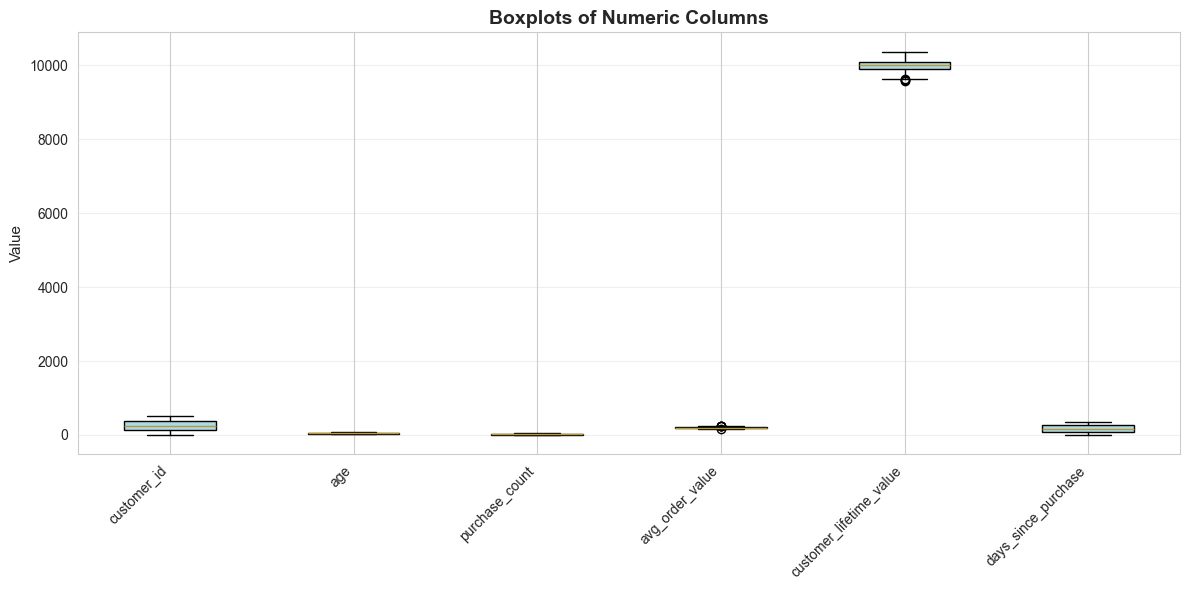

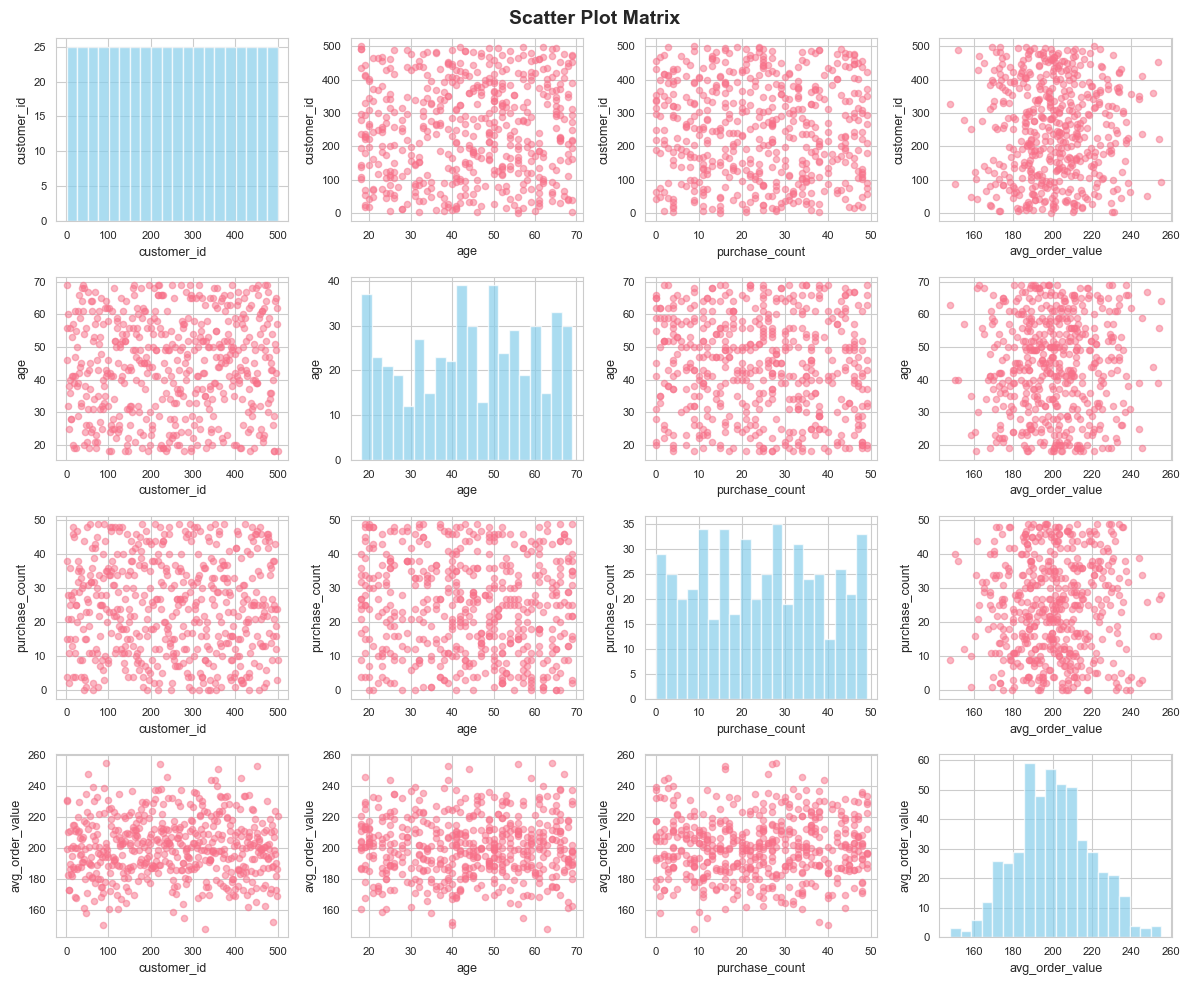

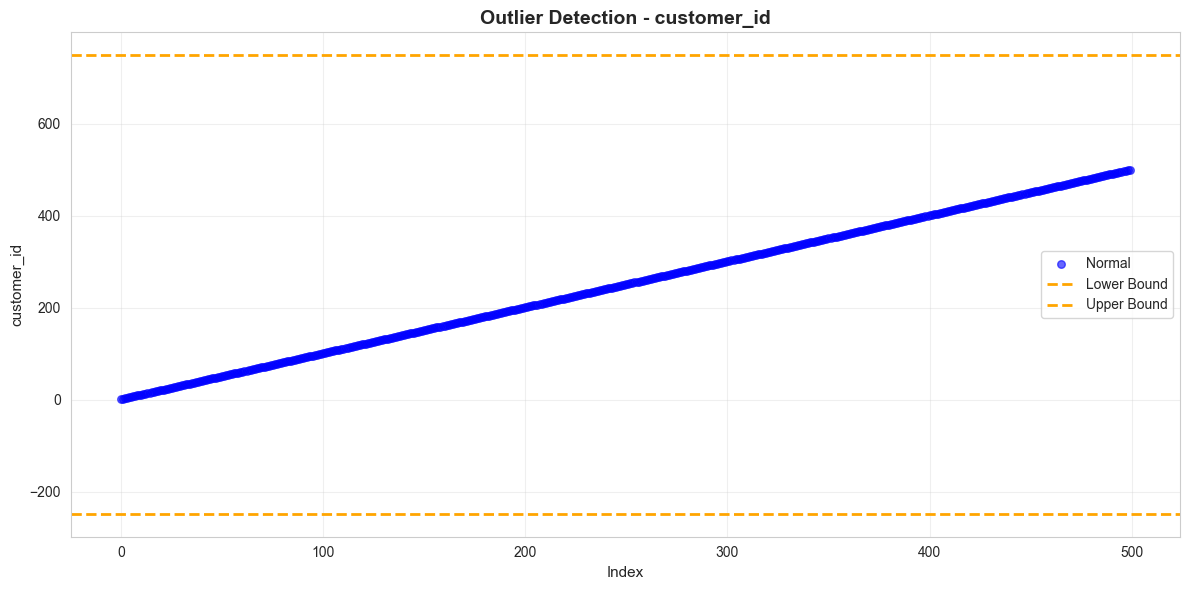

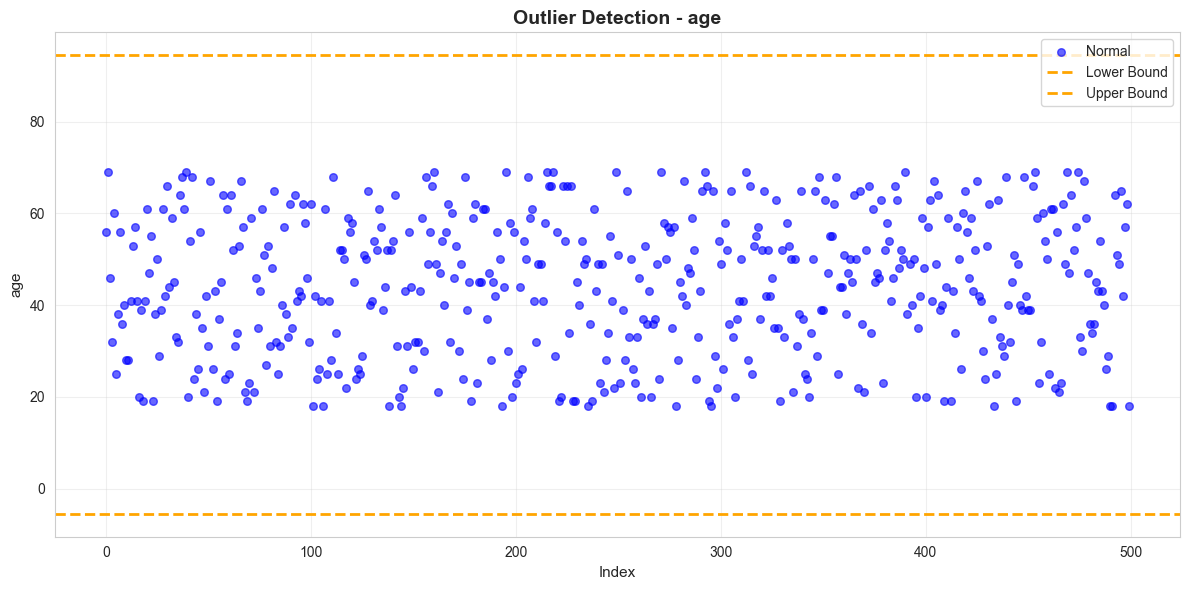

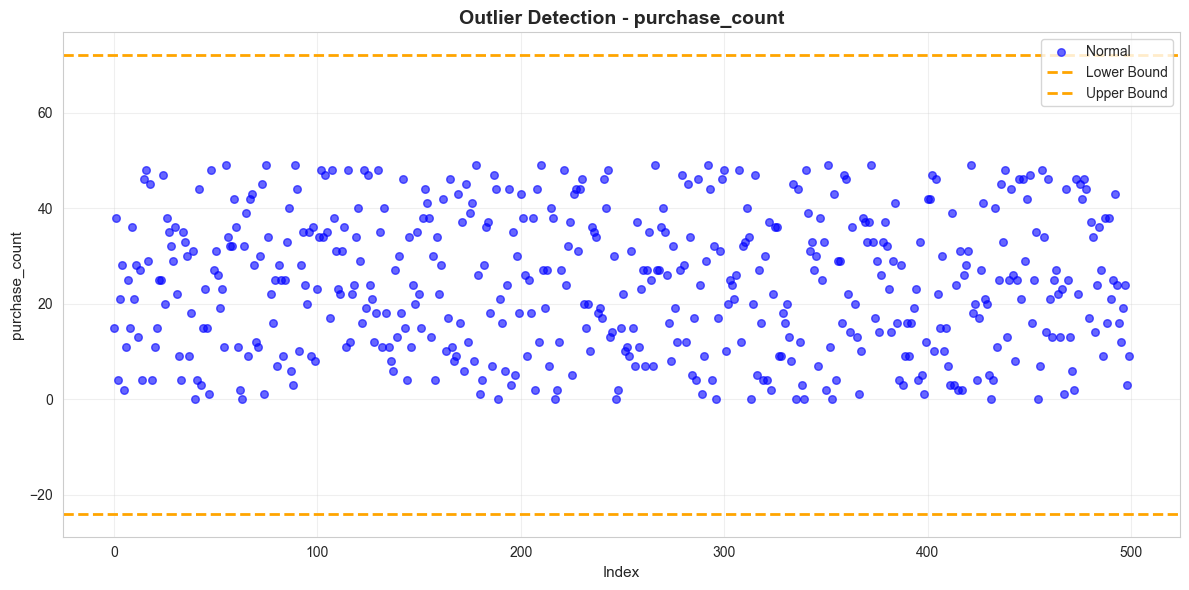

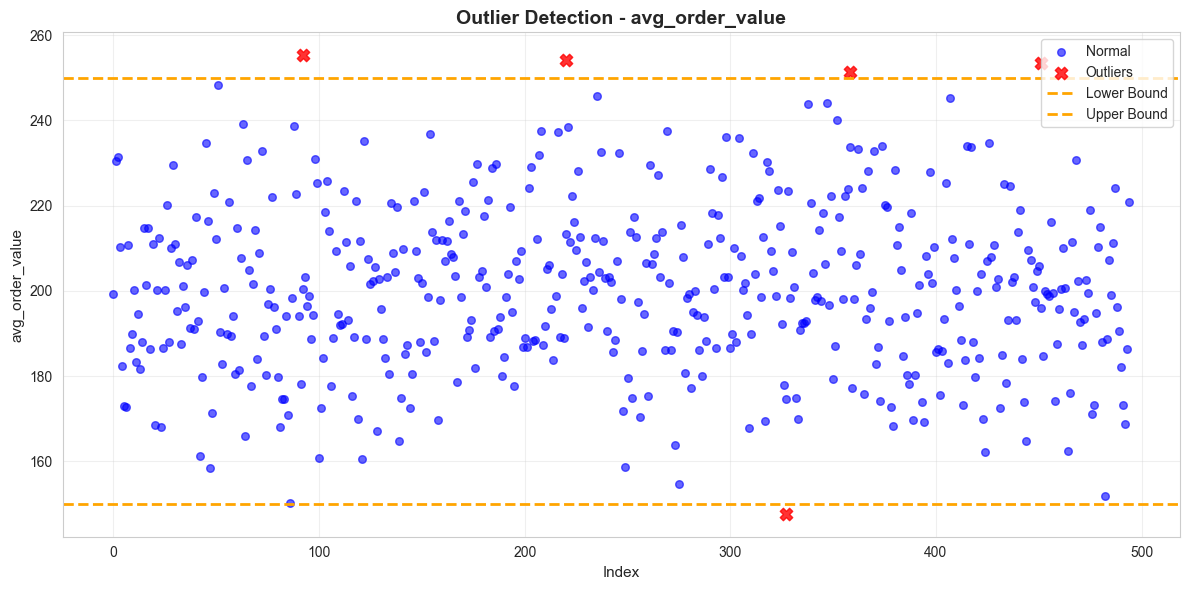

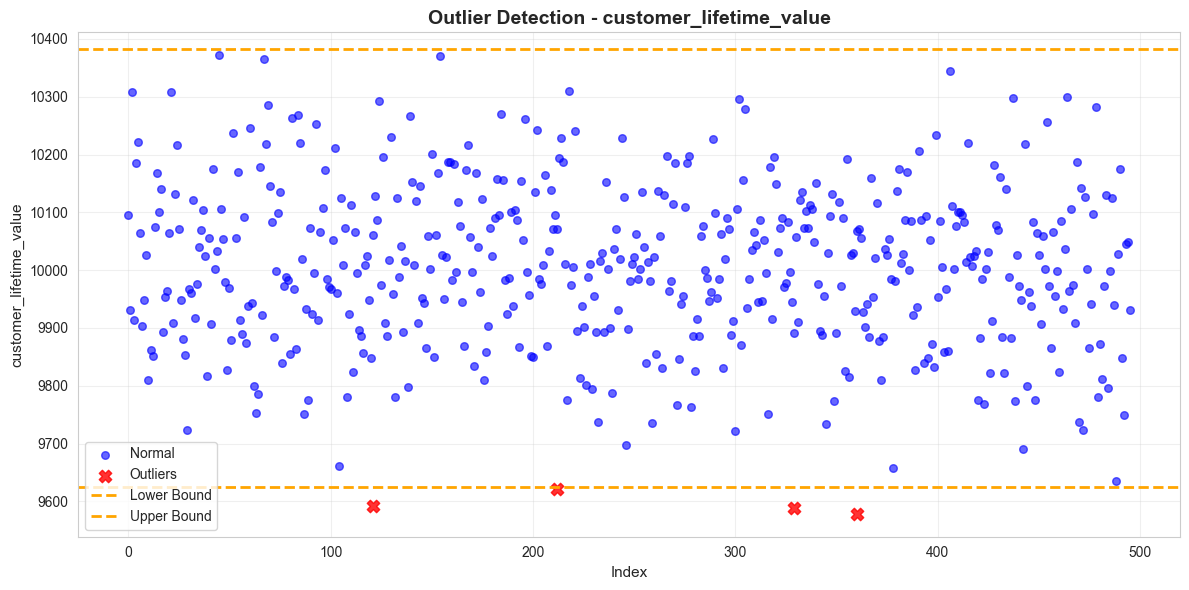

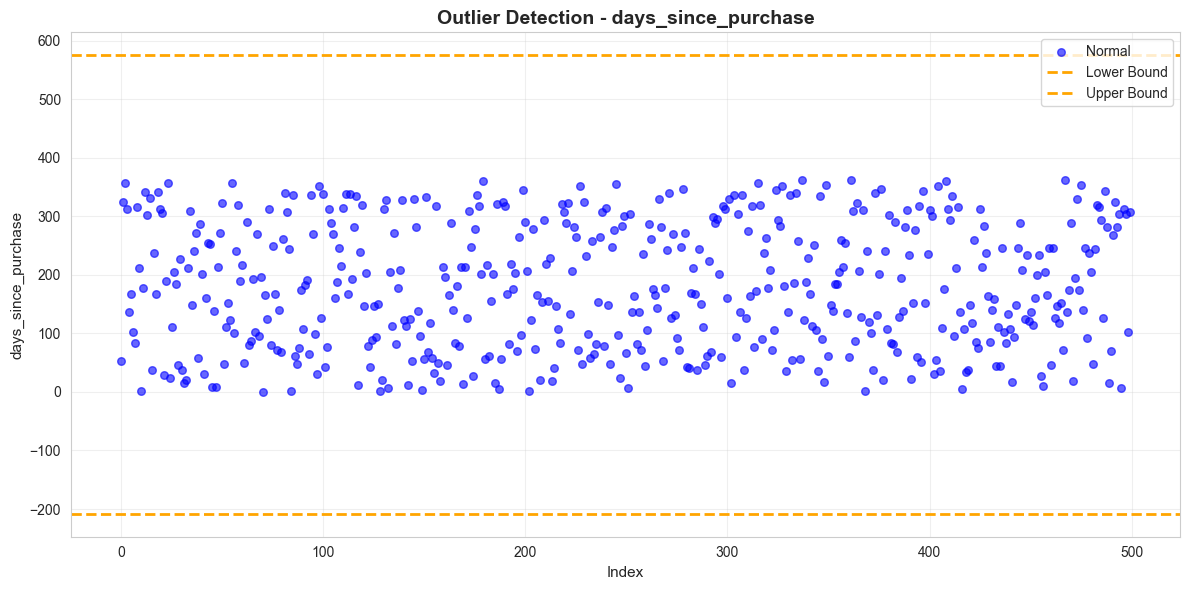

In [4]:
# Example: Full analysis WITH feature engineering
print("\n=== Example 2: Feature Engineering ===")
print("Creating polynomial, interaction, and ratio features automatically...\n")

autolyse_with_features = Autolyse(
    html=False,
    api_key=GEMINI_KEY,
    enable_feature_engineering=True,  # ✓ Enable automatic feature creation
    enable_statistics=True,
    enable_correlations=True,
    enable_visualizations=True
)

results_with_features = autolyse_with_features.analyse(ecommerce_df, show_progress=True)

In [5]:
# Show the engineered features
print("\nDataset shape comparison:")
print(f"  Original: {ecommerce_df.shape}")
print(f"  After feature engineering: {autolyse_with_features.df.shape}")
print(f"\nNew features created: {autolyse_with_features.df.shape[1] - ecommerce_df.shape[1]}")

# Show some of the engineered feature names
original_cols = set(ecommerce_df.columns)
new_cols = [col for col in autolyse_with_features.df.columns if col not in original_cols]
print(f"\nEngineered features (sample):")
for feat in new_cols[:10]:
    print(f"  - {feat}")


Dataset shape comparison:
  Original: (500, 8)
  After feature engineering: (500, 8)

New features created: 0

Engineered features (sample):


## Example 3: Random Seeding - Reproducible Analysis

Use random_seed parameter to ensure exact reproducibility across runs.


=== Example 3: Random Seeding for Reproducibility ===
Running same analysis twice with fixed random_seed=42...



# Automated EDA Analysis - Autolyse

## Dataset Summary


**Dataset Shape:** 500 rows × 8 columns

**Column Information:**
- Numeric Columns: 6
- Categorical Columns: 2
- Date Columns: 0
- Missing Values: 0
        

## Column Information

...

### Distributions

### Missing Values

### Correlation Heatmap

### Boxplots

Results comparison (should be identical with same seed):
  ✓ Outlier detection results: IDENTICAL


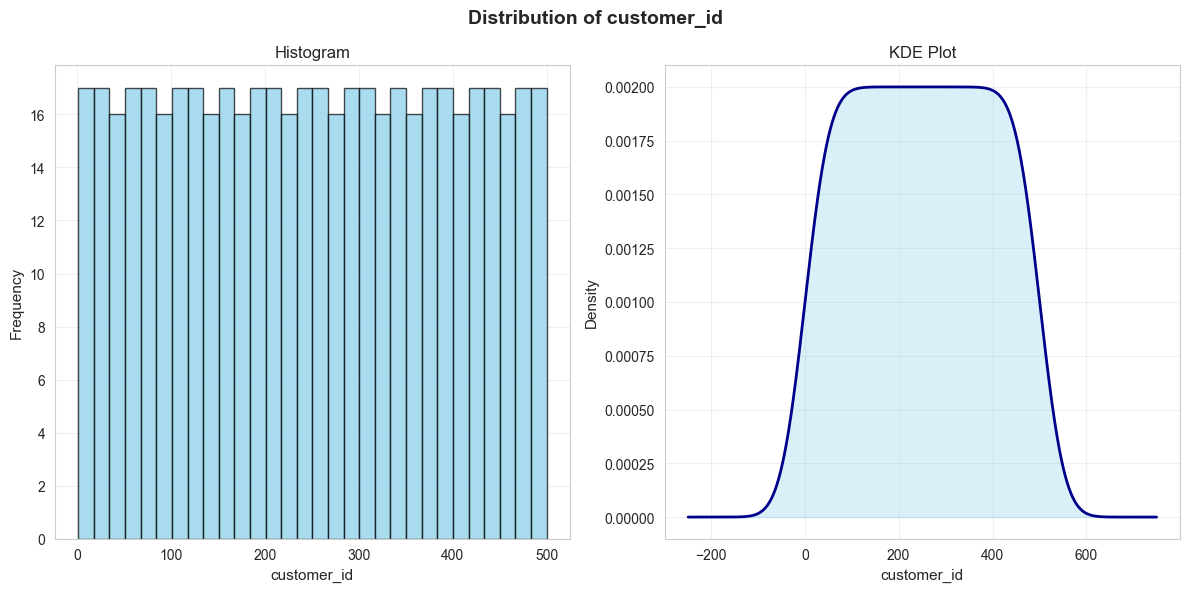

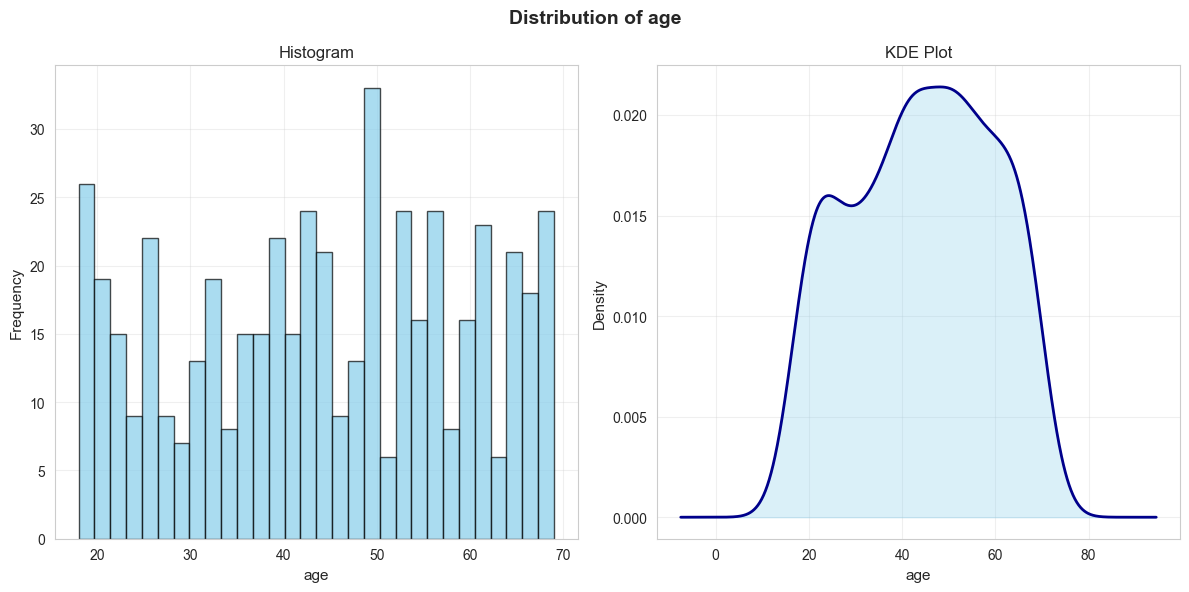

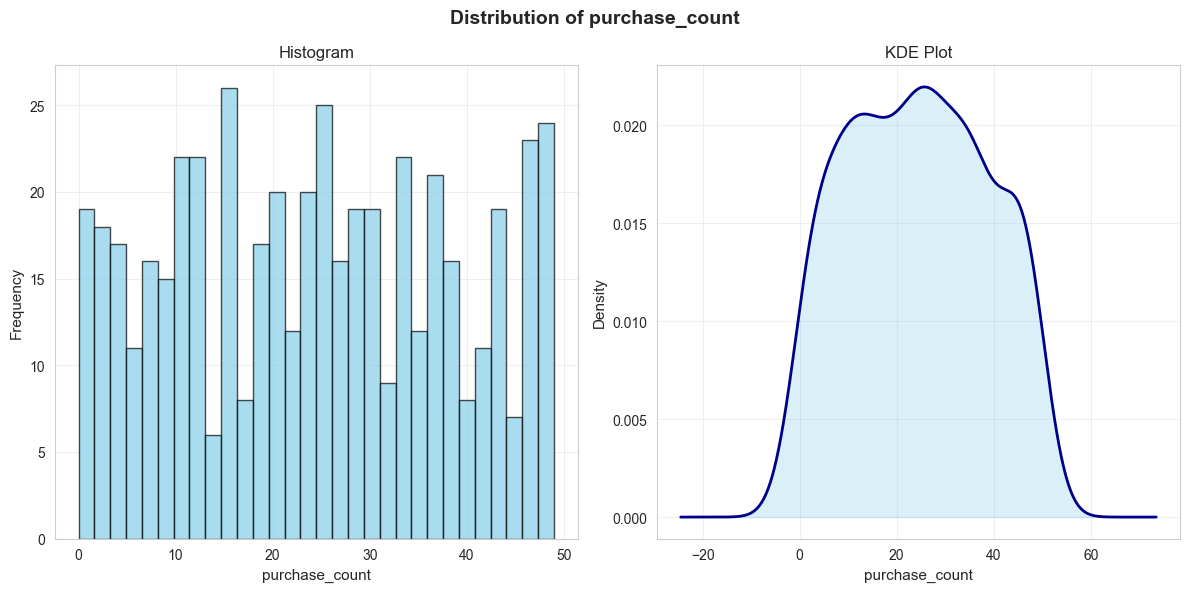

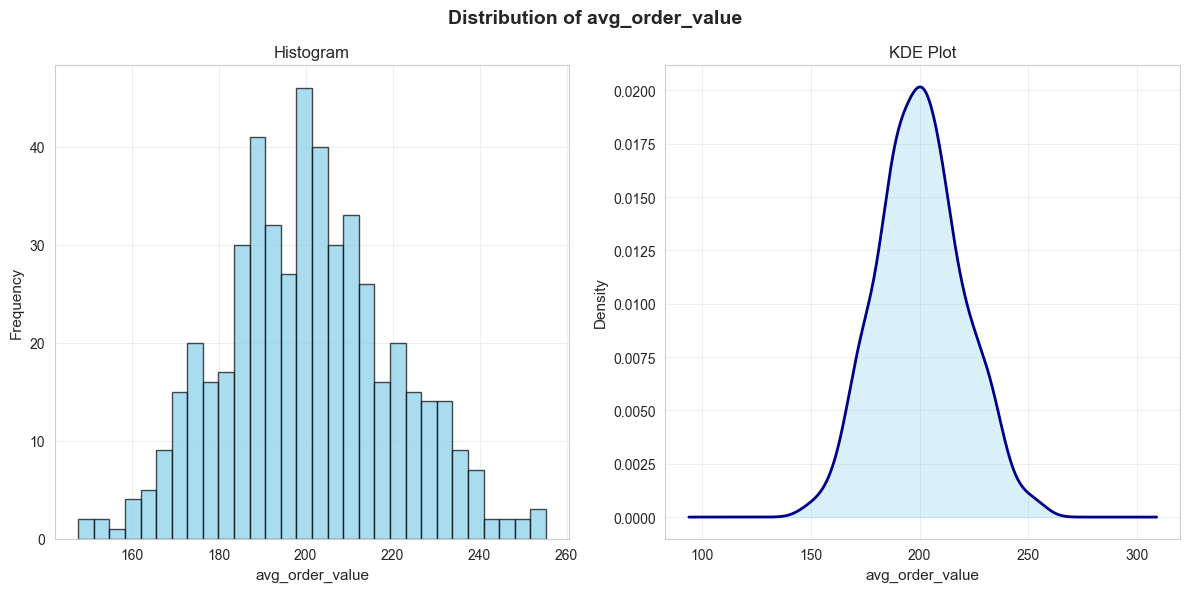

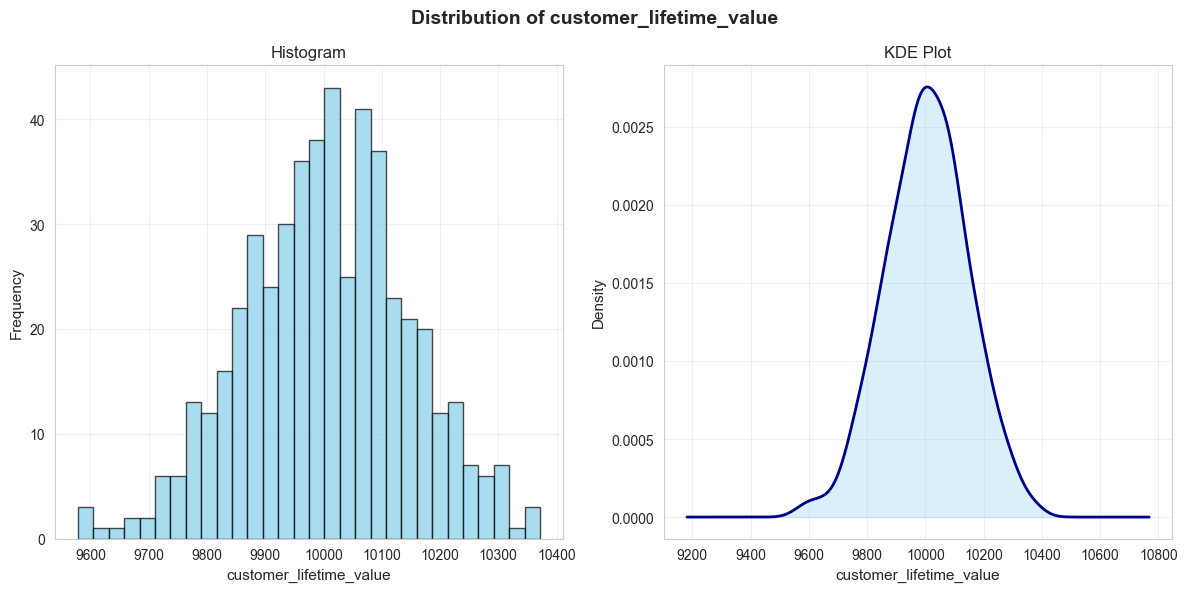

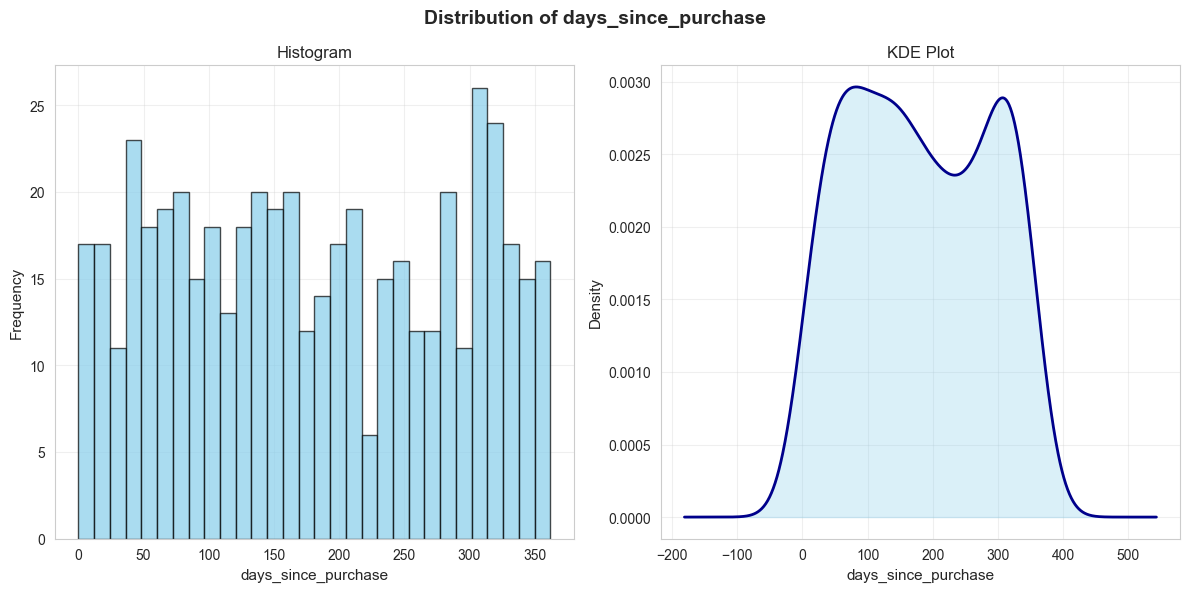

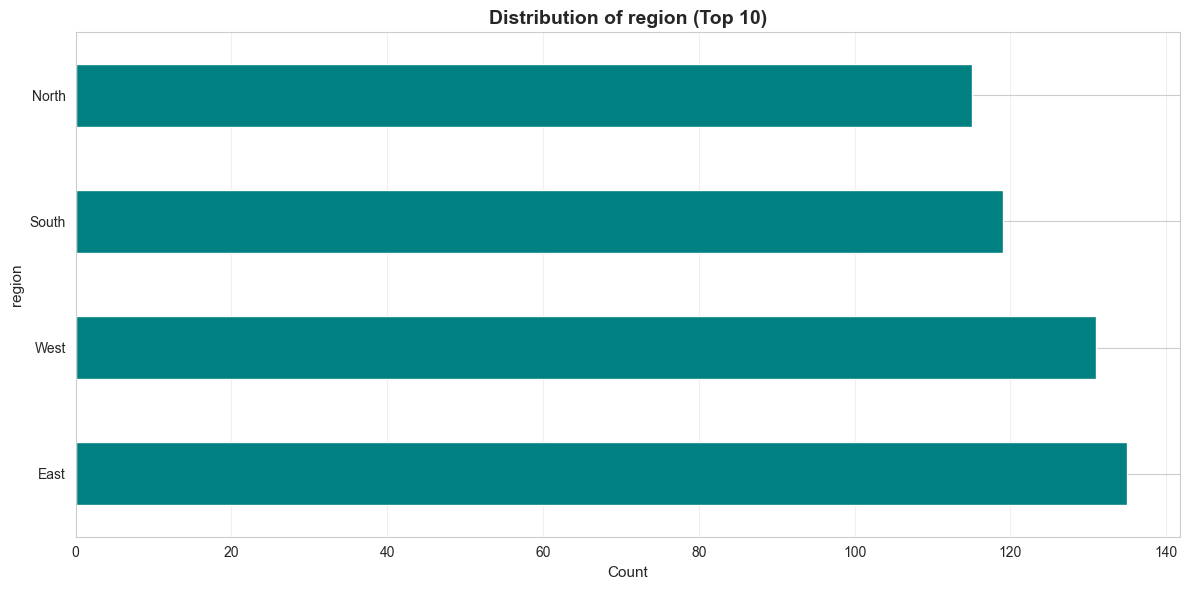

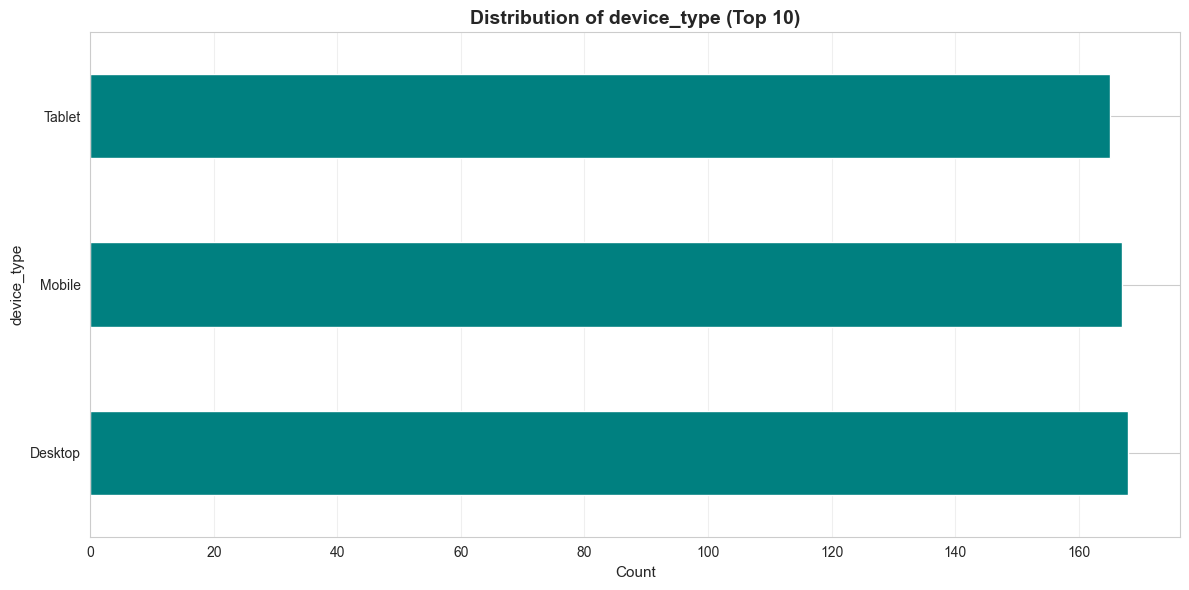

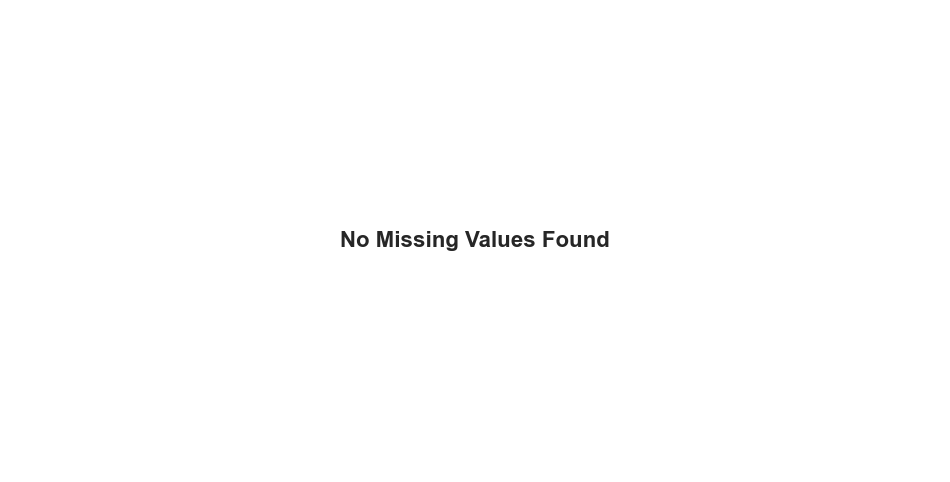

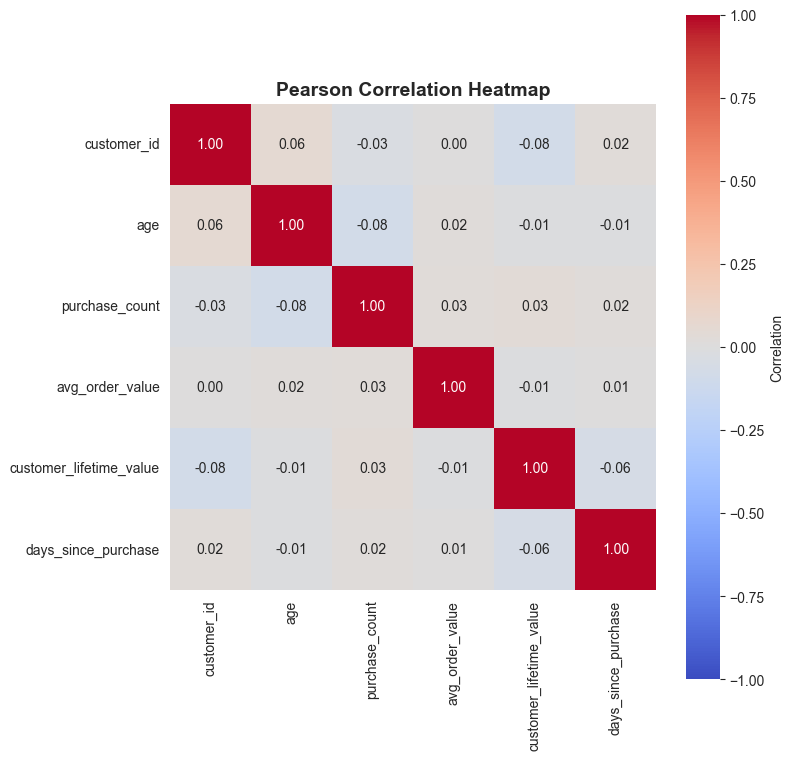

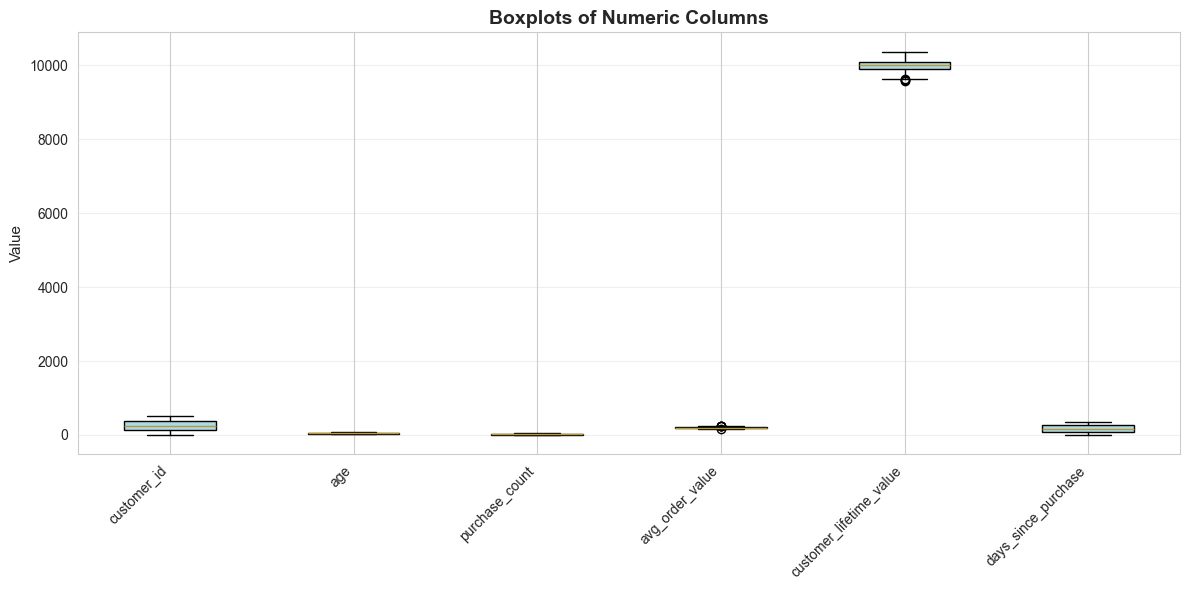

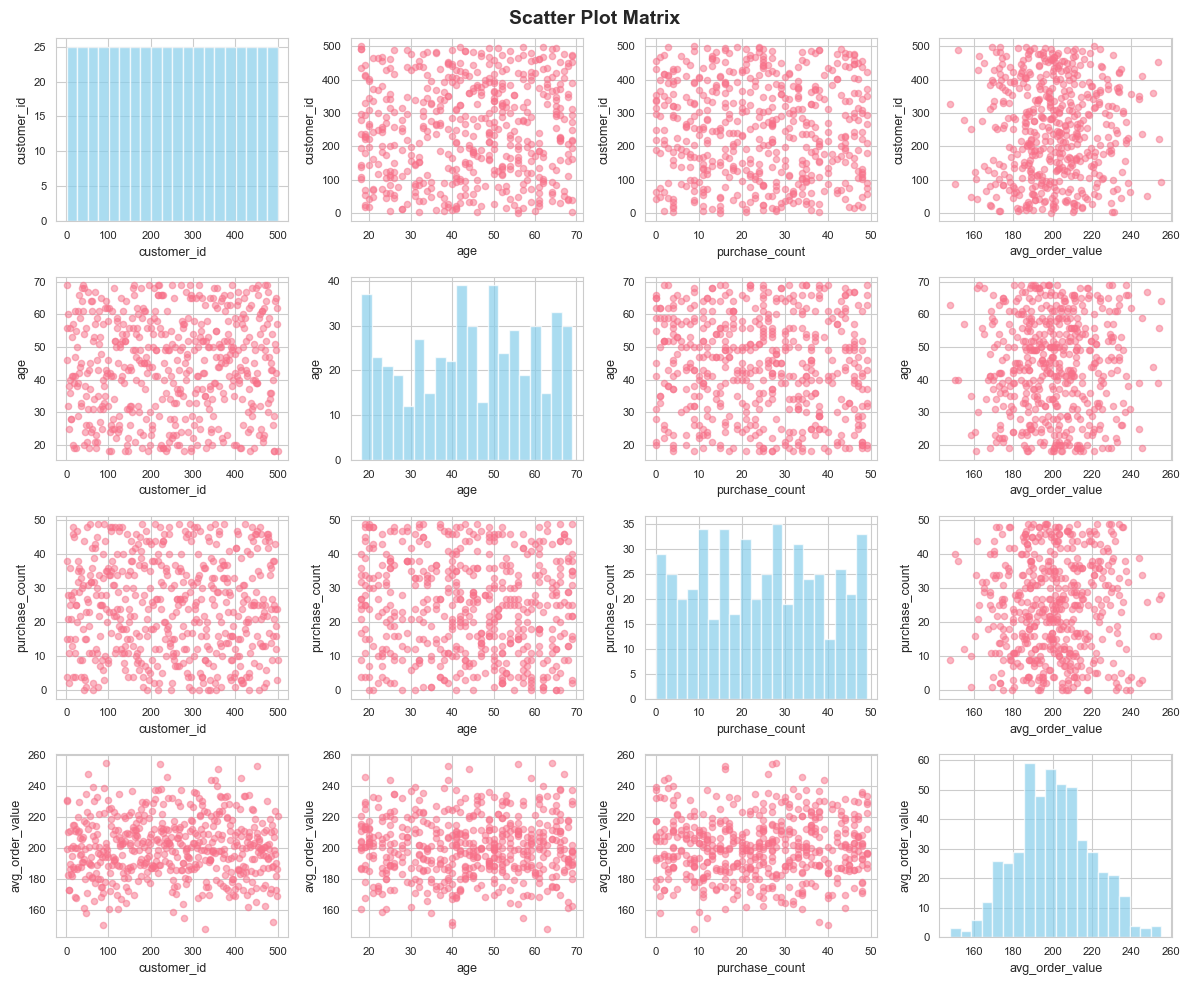

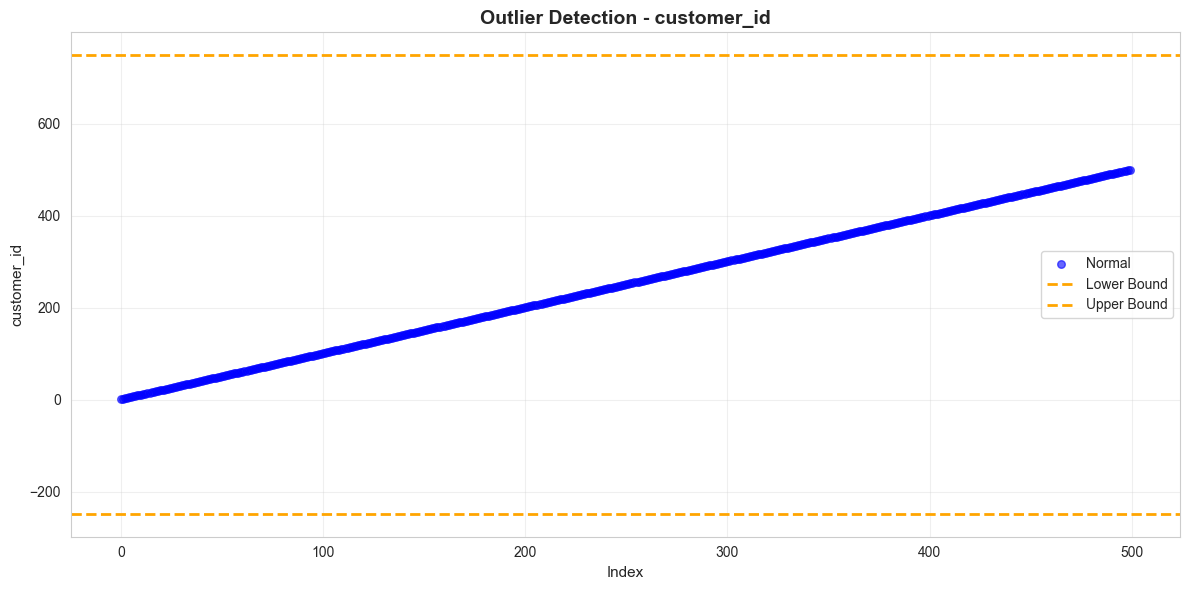

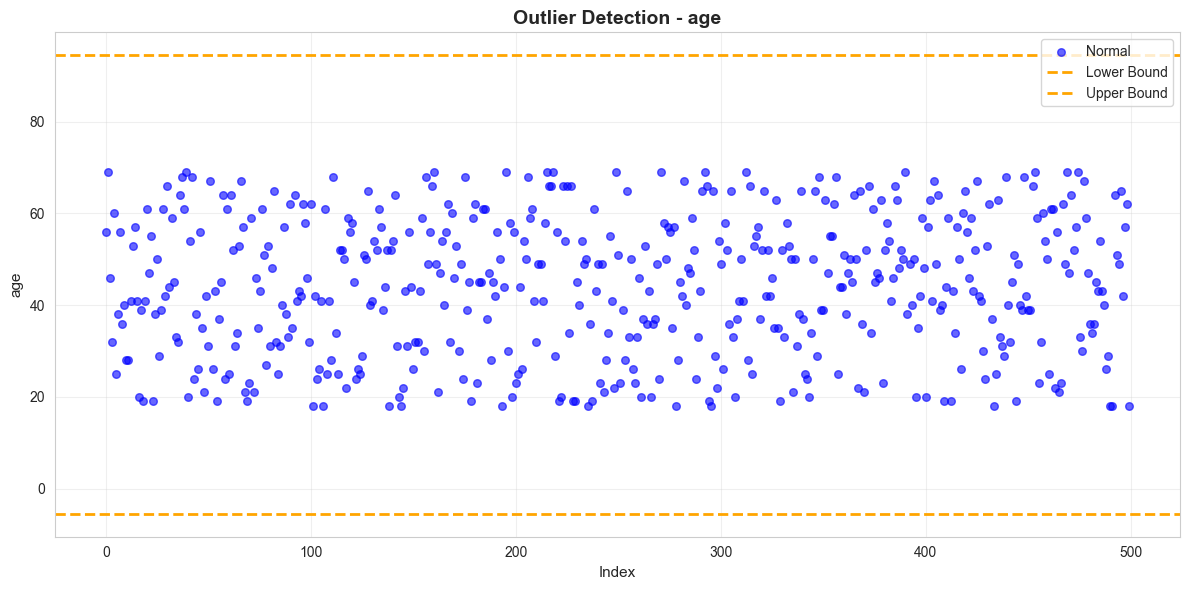

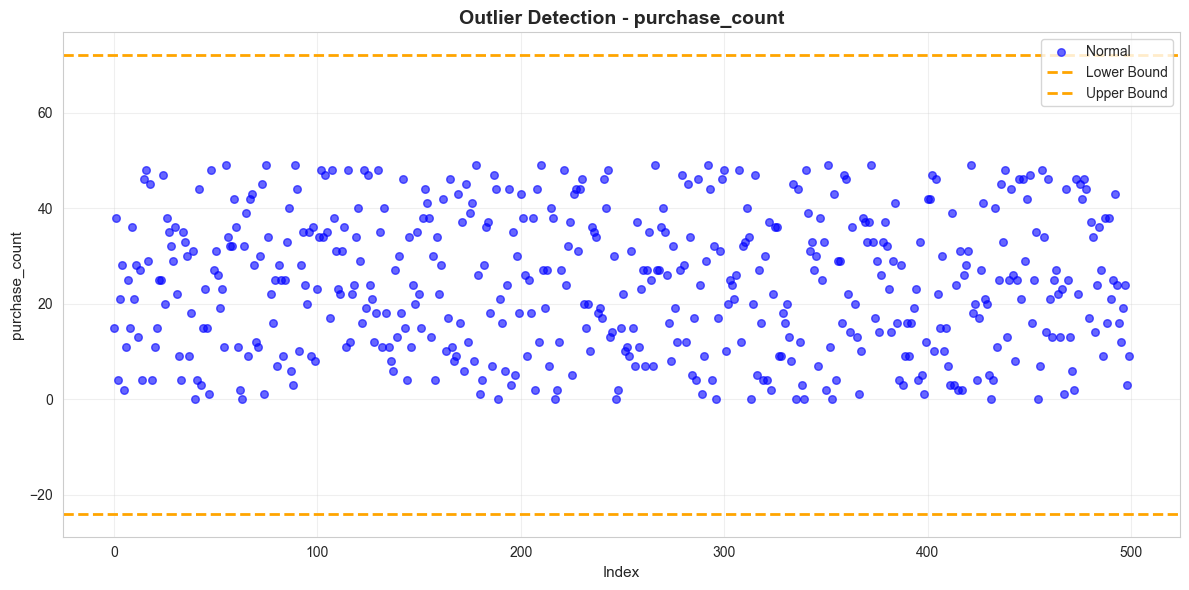

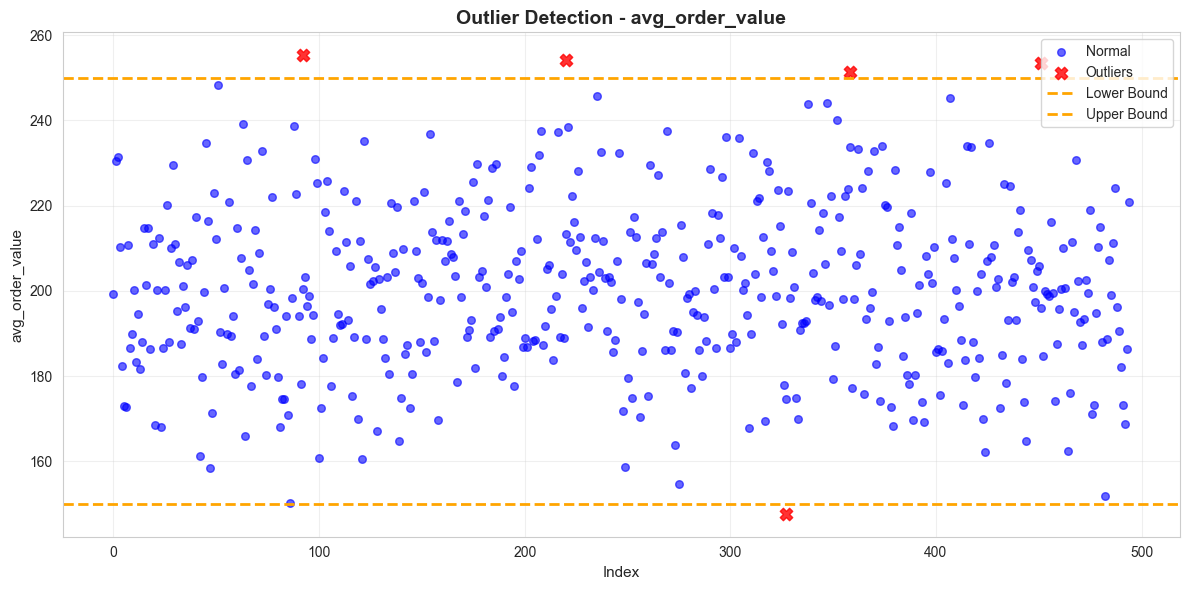

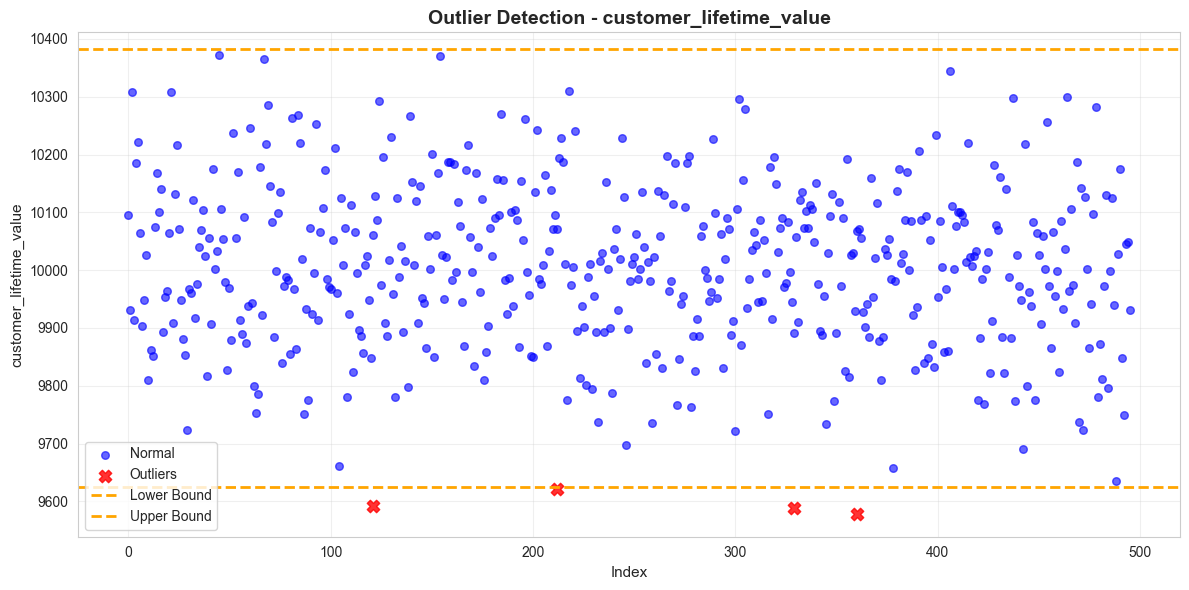

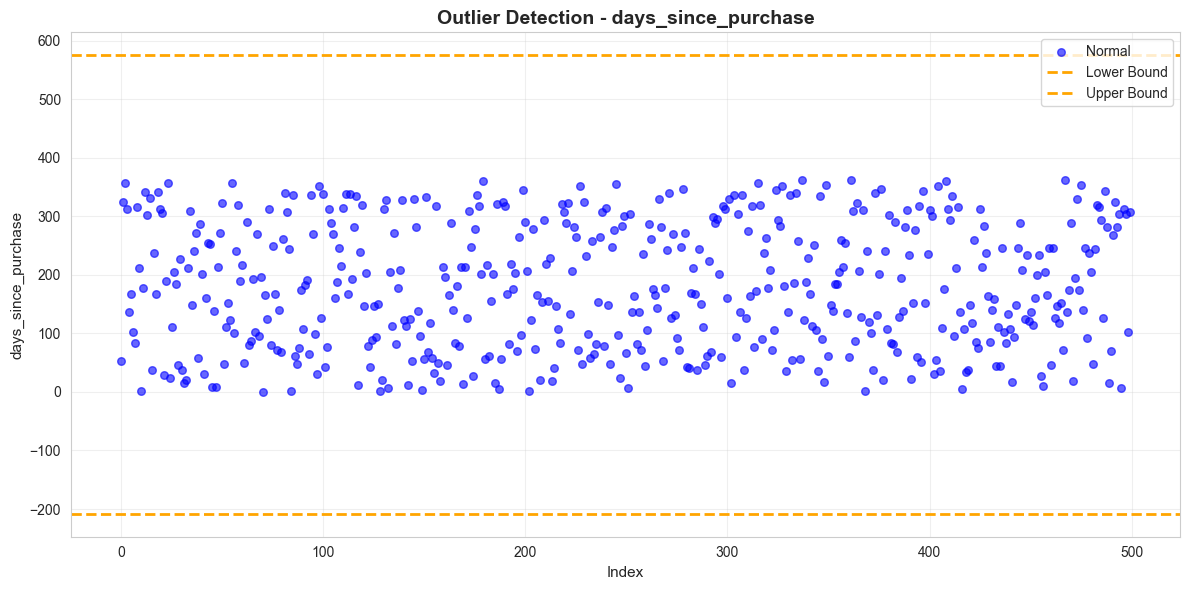

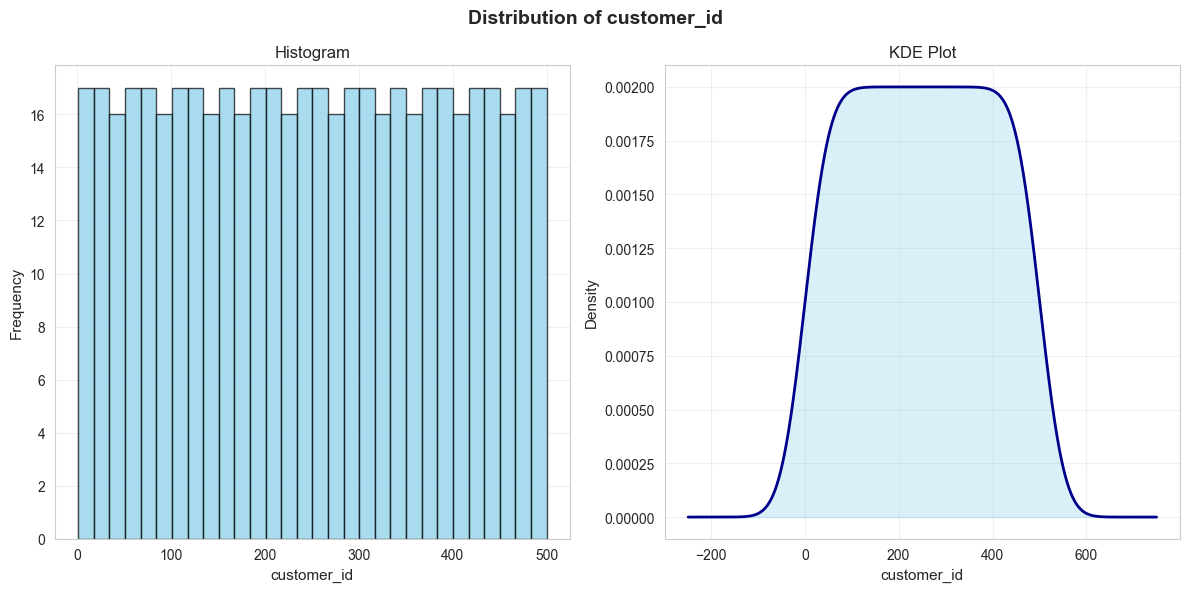

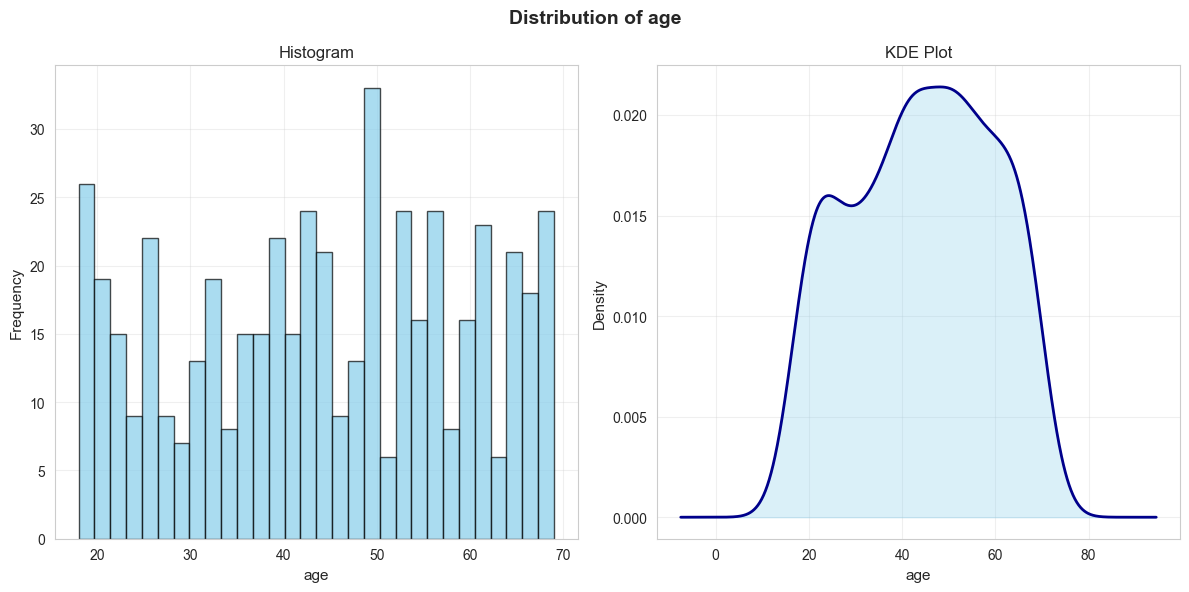

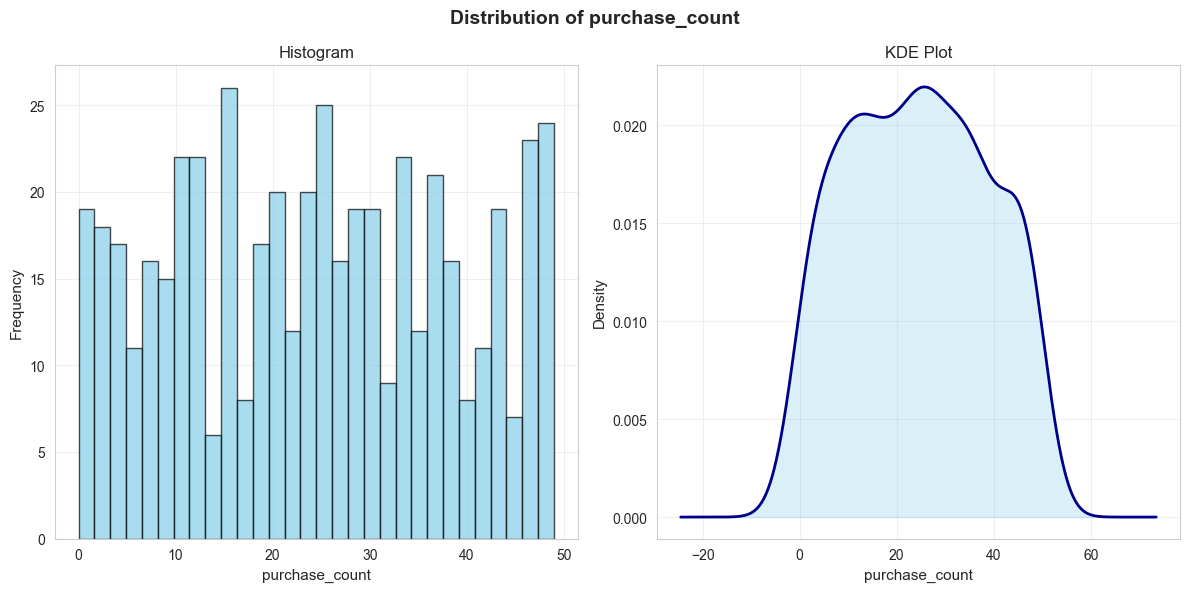

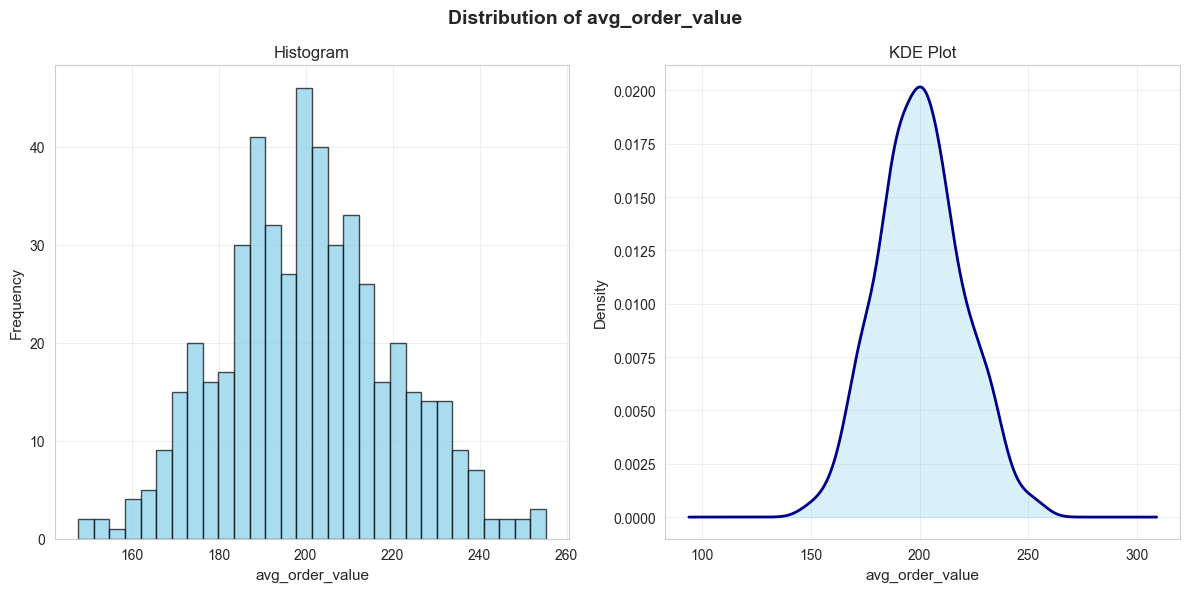

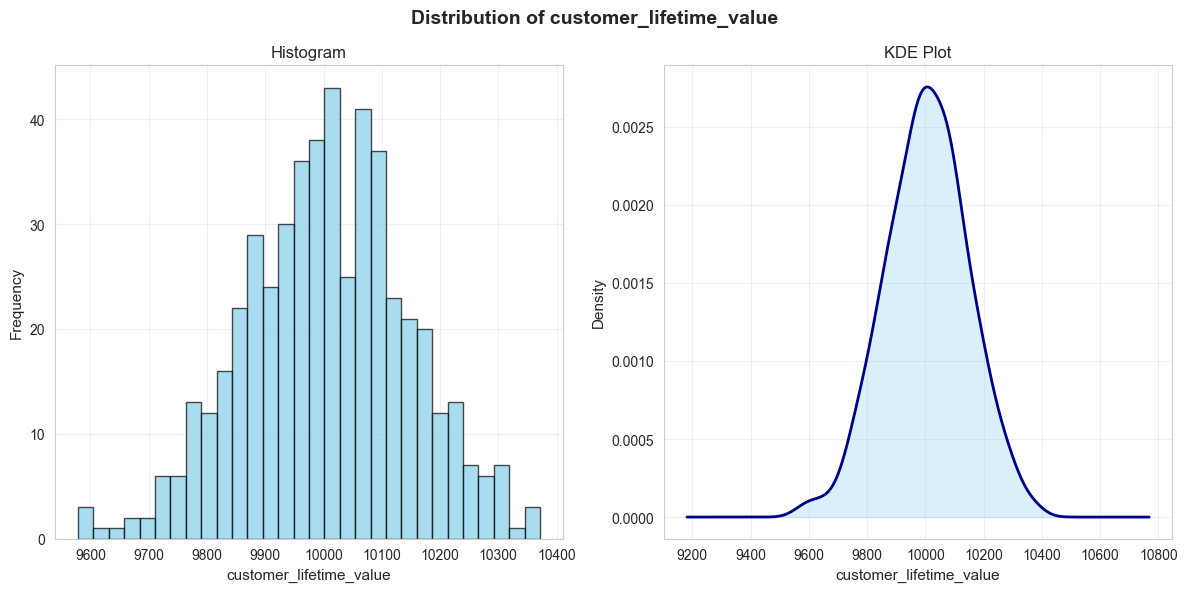

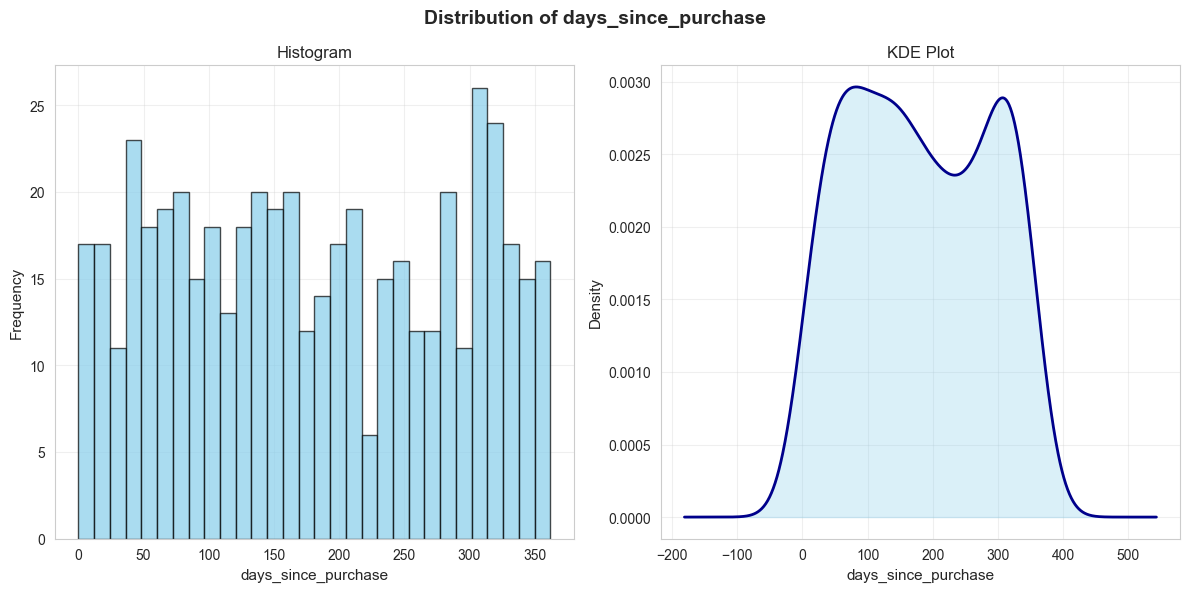

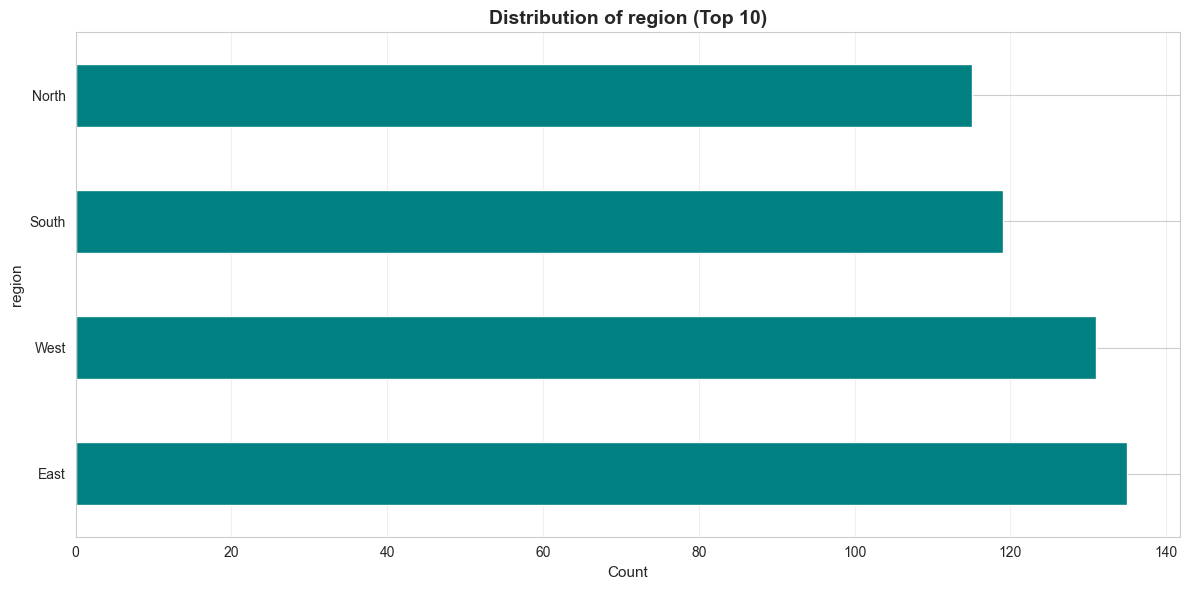

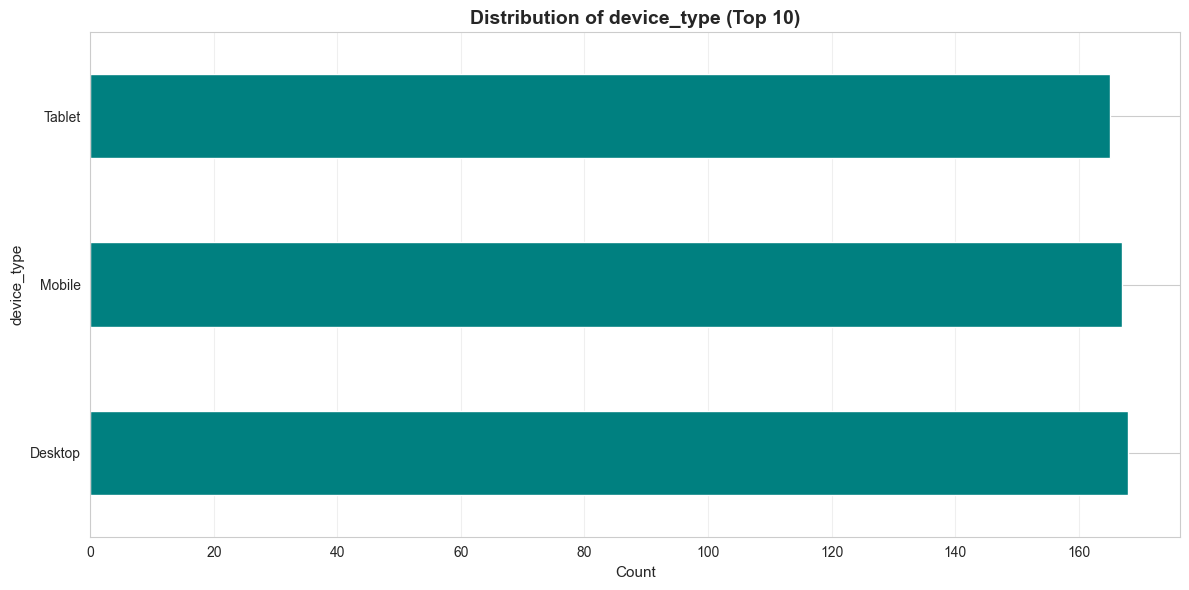

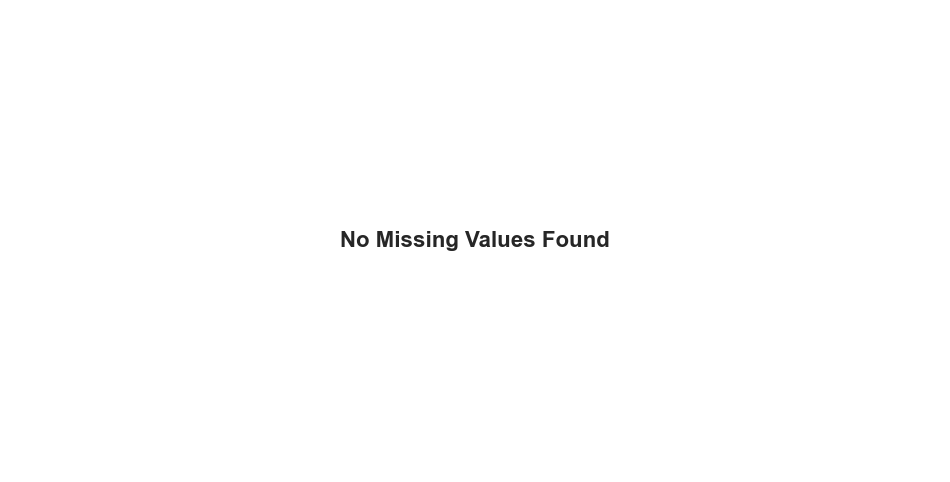

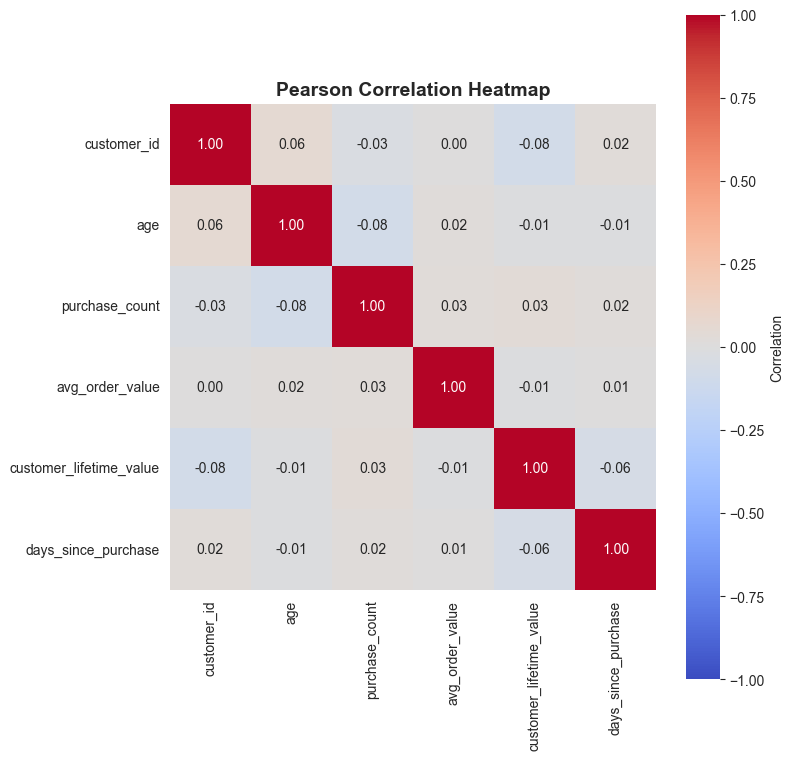

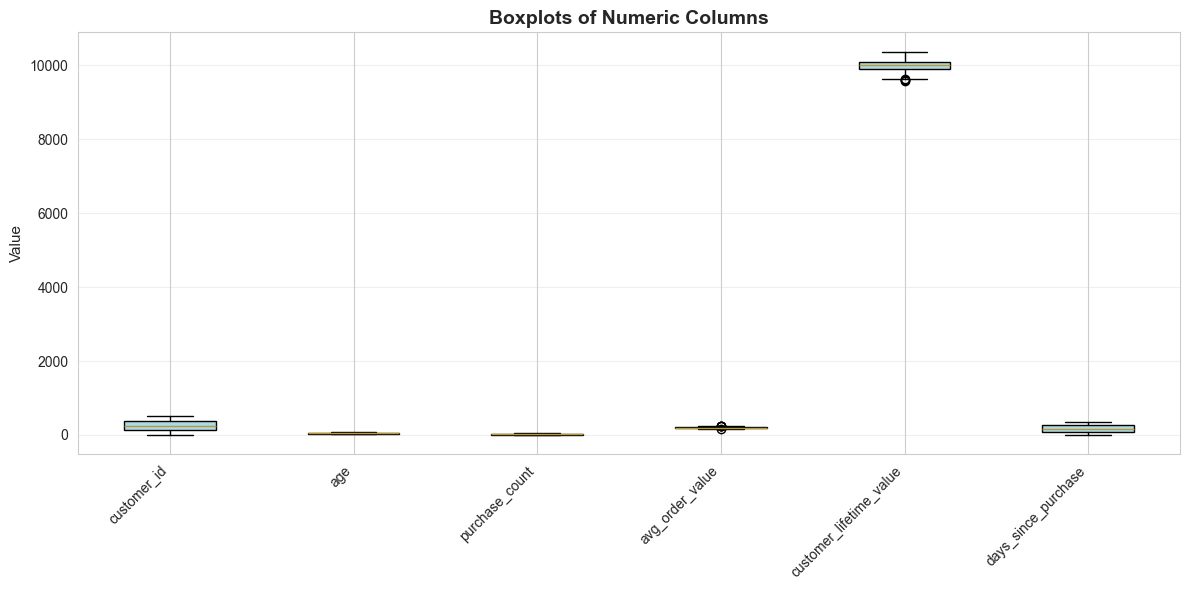

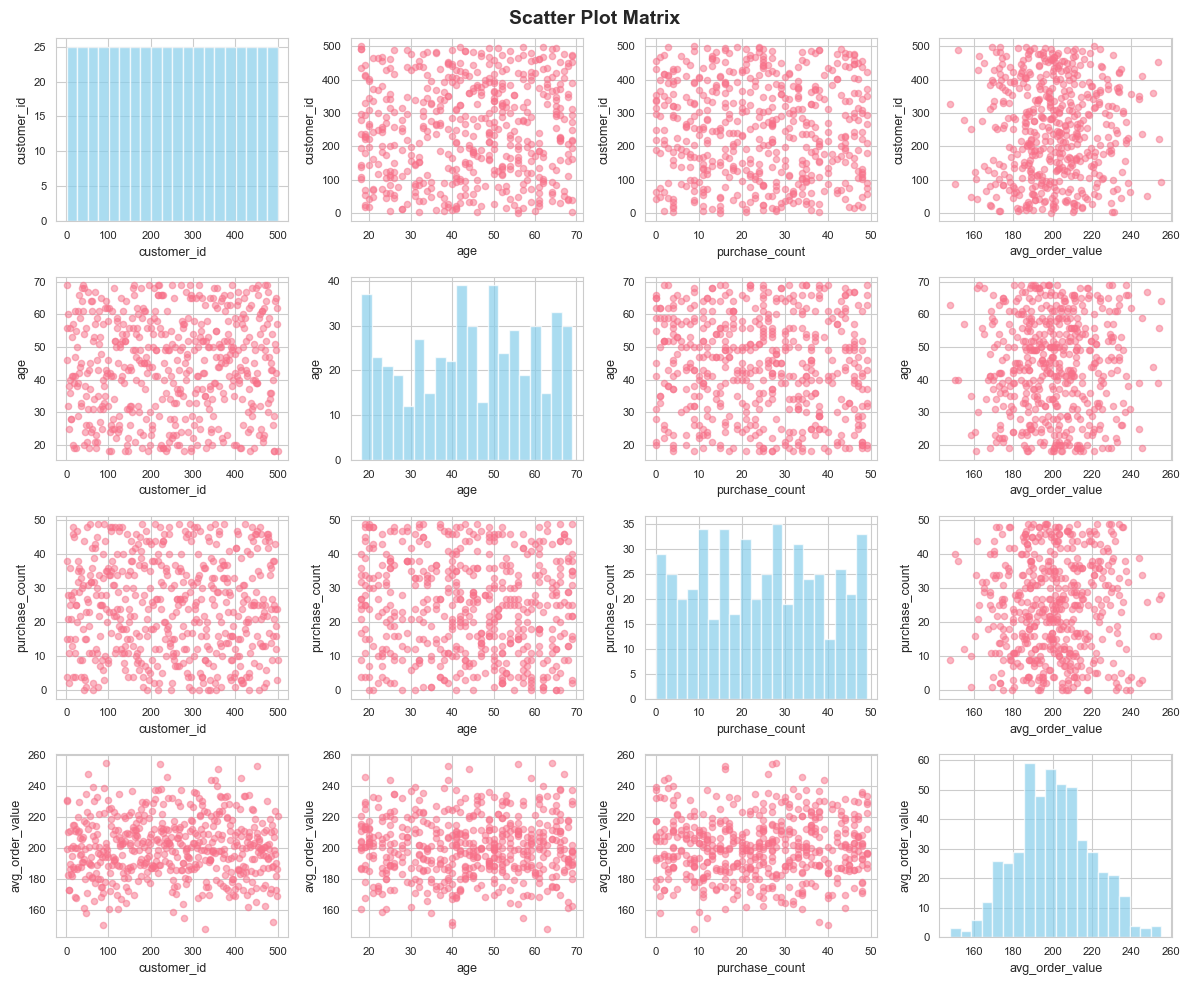

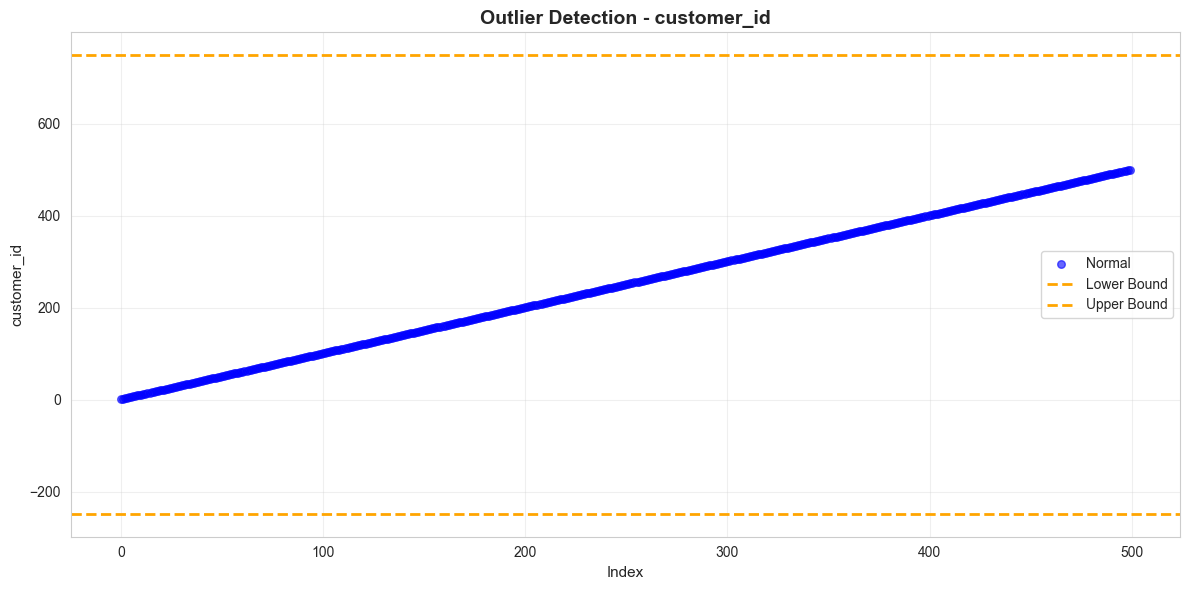

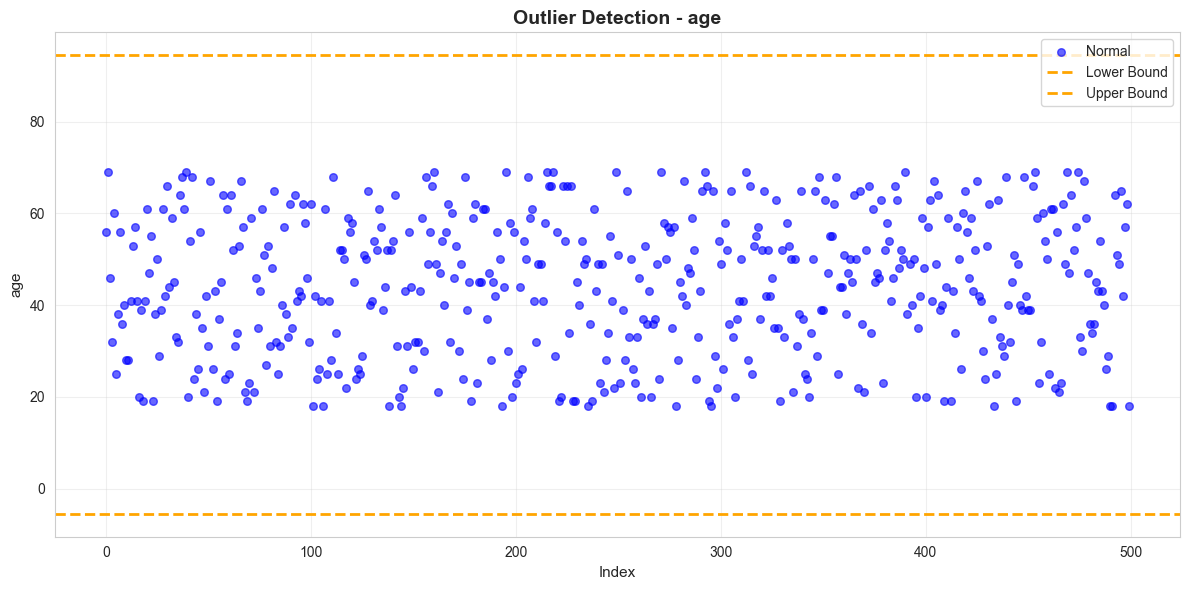

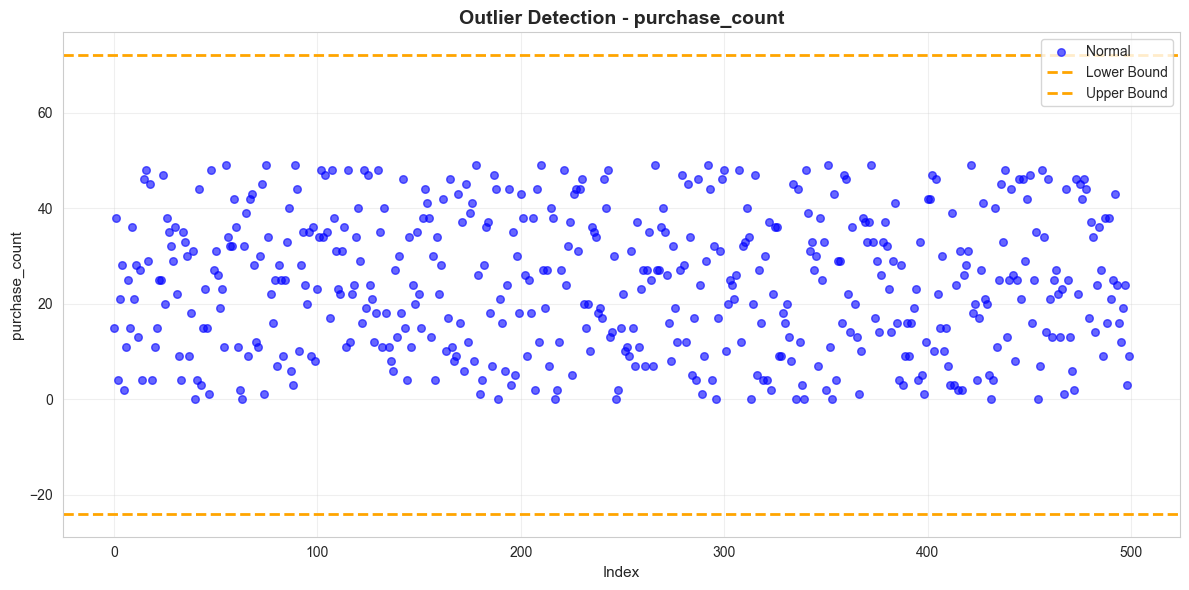

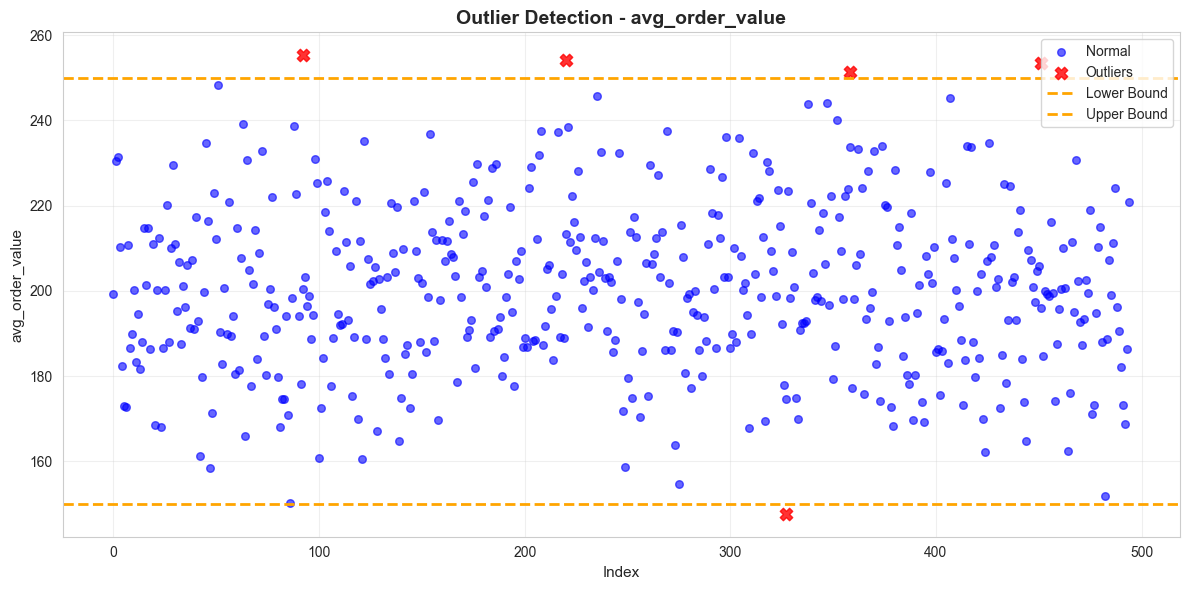

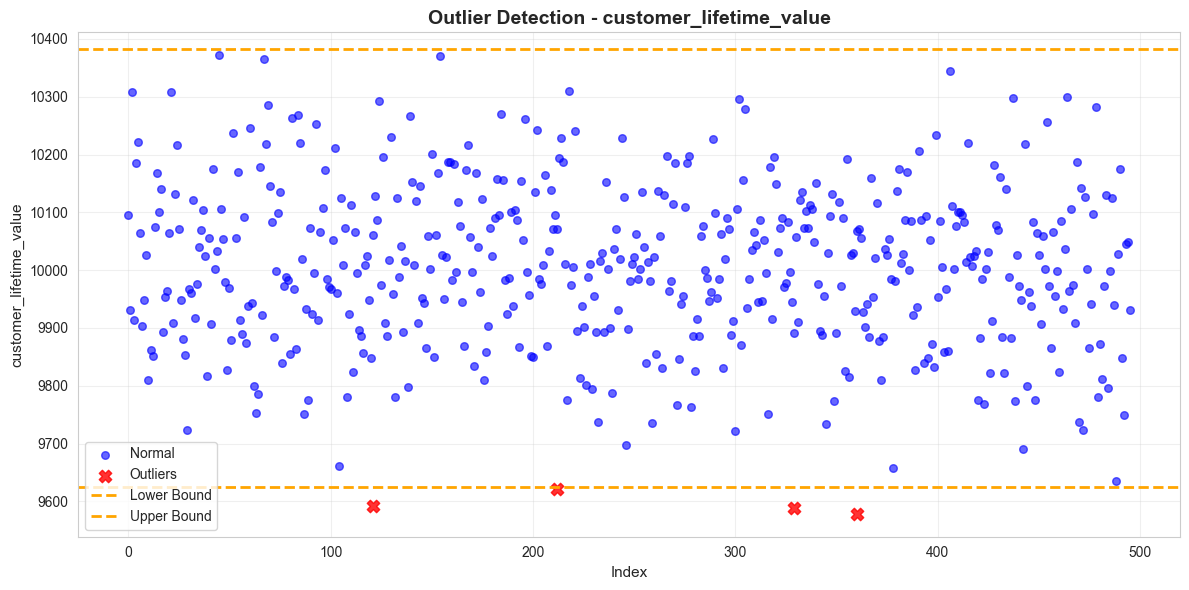

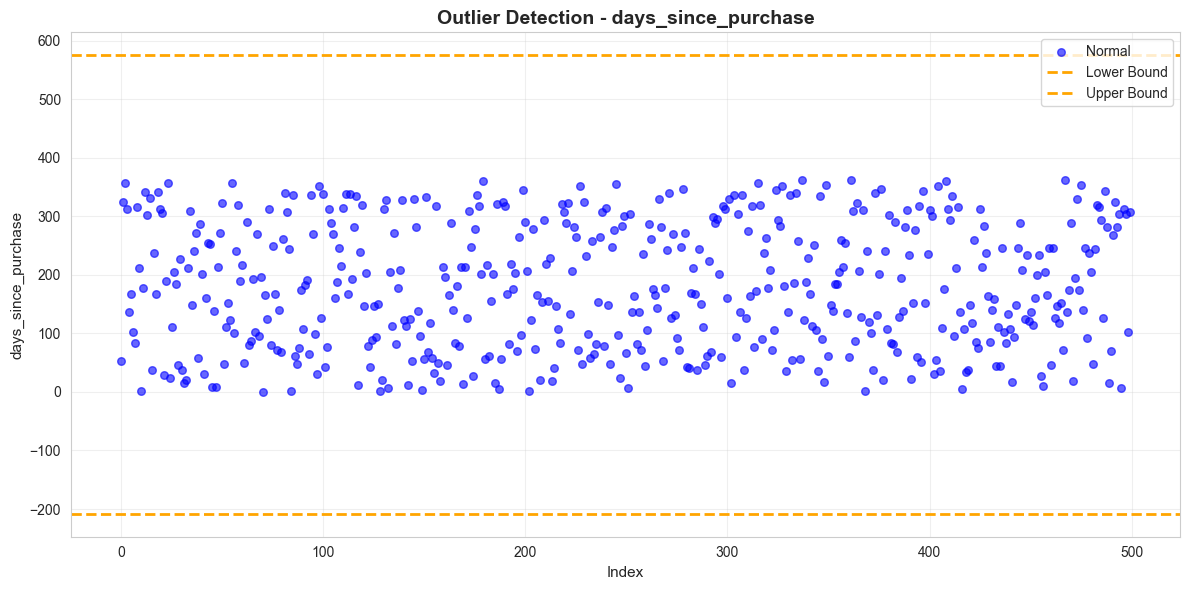

In [6]:
print("\n=== Example 3: Random Seeding for Reproducibility ===")
print("Running same analysis twice with fixed random_seed=42...\n")

# Run 1
autolyse_seed1 = Autolyse(
    html=False,
    api_key=GEMINI_KEY,
    random_seed=42,  # Fixed seed
    enable_outliers=True,
    enable_advanced_insights=True
)

results_1 = autolyse_seed1.analyse(ecommerce_df, show_progress=False)

# Run 2 - same seed
autolyse_seed2 = Autolyse(
    html=False,
    api_key=GEMINI_KEY,
    random_seed=42,  # Same seed
    enable_outliers=True,
    enable_advanced_insights=True
)

results_2 = autolyse_seed2.analyse(ecommerce_df, show_progress=False)

print("Results comparison (should be identical with same seed):")
outliers_1 = results_1.get('outliers', {}).get('iqr_method', {})
outliers_2 = results_2.get('outliers', {}).get('iqr_method', {})

if outliers_1 == outliers_2:
    print("  ✓ Outlier detection results: IDENTICAL")
else:
    print("  ✗ Outlier detection results: DIFFERENT")

## Example 4: Batch Sampling - Fast Analysis on Large Datasets

Use batch_size to sample rows for quick iteration.


=== Example 4: Batch Sampling ===
Large dataset size: 10000 rows

Running analysis on 1000-row sample for speed...

📊 Sampling 1000 rows from 10000 rows for faster analysis...
Starting Autolyse Analysis...
Dataset: 1000 rows × 5 columns

1️⃣  Analyzing data structure and types...
2️⃣  Running analyzers (7 enabled)...
3️⃣  Generating visualizations (matplotlib + plotly)...
4️⃣  Generating AI insights...
5️⃣  Preparing output...


# Automated EDA Analysis - Autolyse

## Dataset Summary


**Dataset Shape:** 1000 rows × 5 columns

**Column Information:**
- Numeric Columns: 4
- Categorical Columns: 1
- Date Columns: 0
- Missing Values: 0
        

## Column Information

...

## Visualizations

### Distributions

### Missing Values

### Correlation Heatmap

### Boxplots

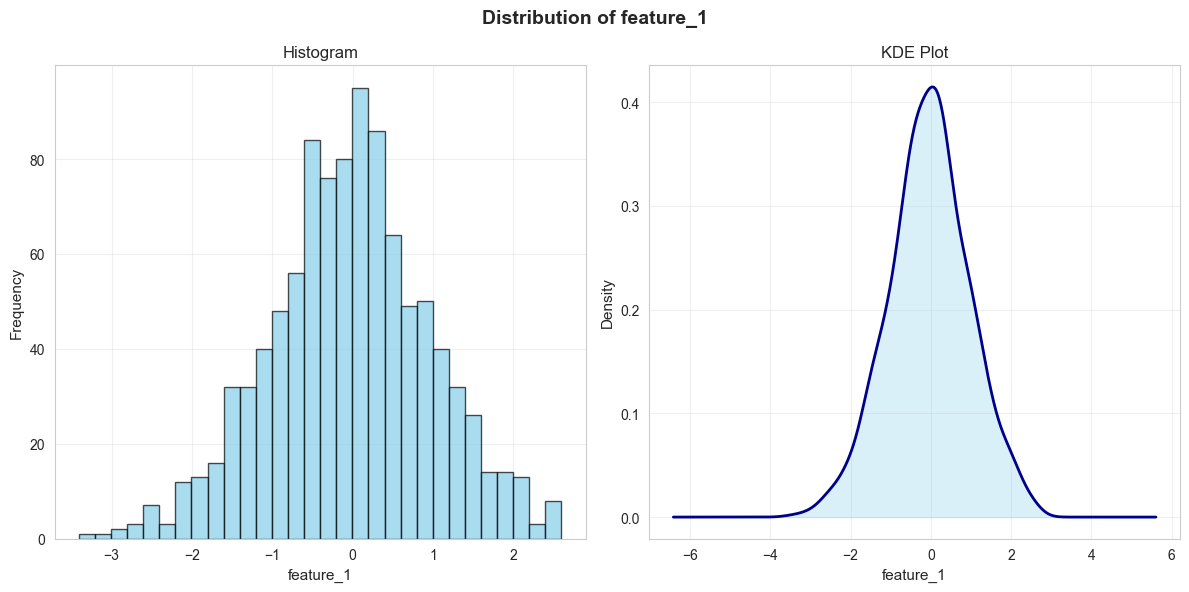

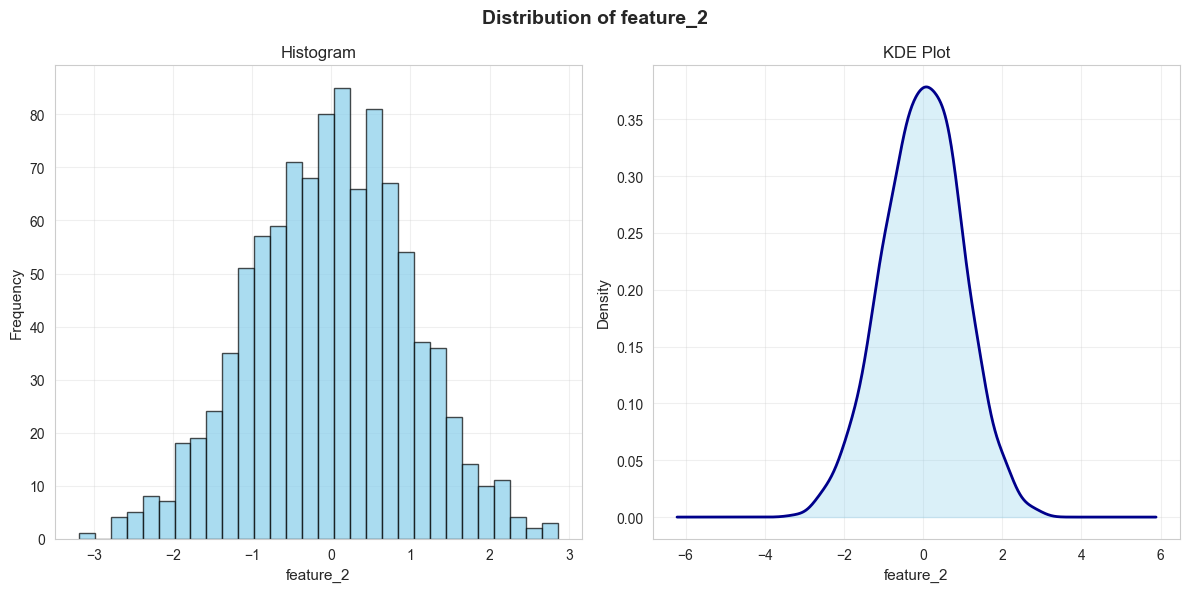

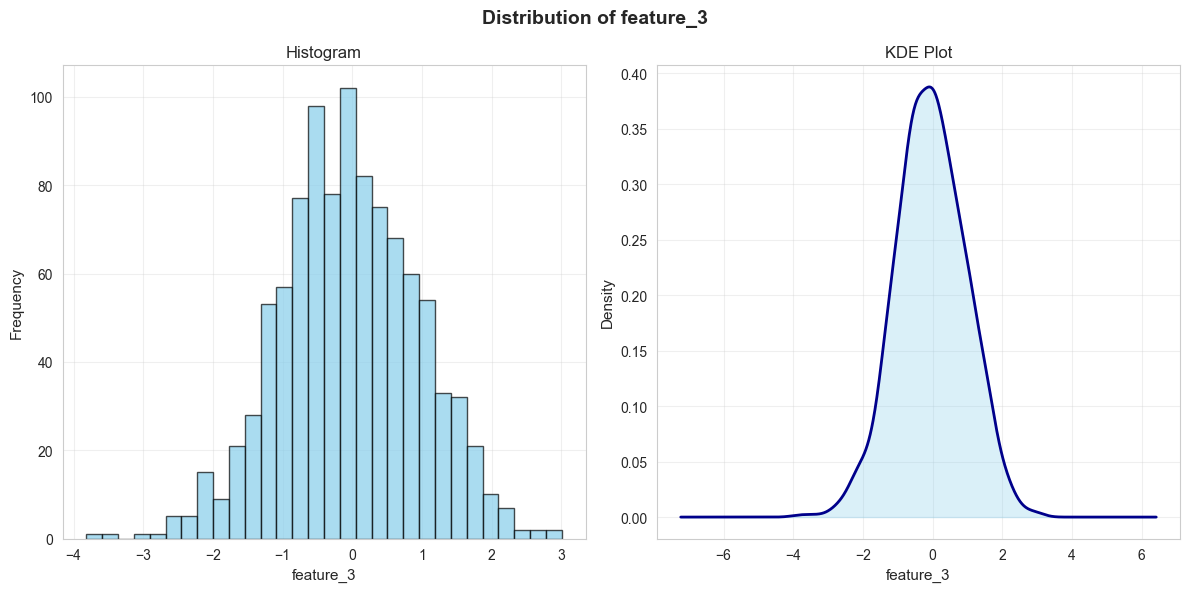

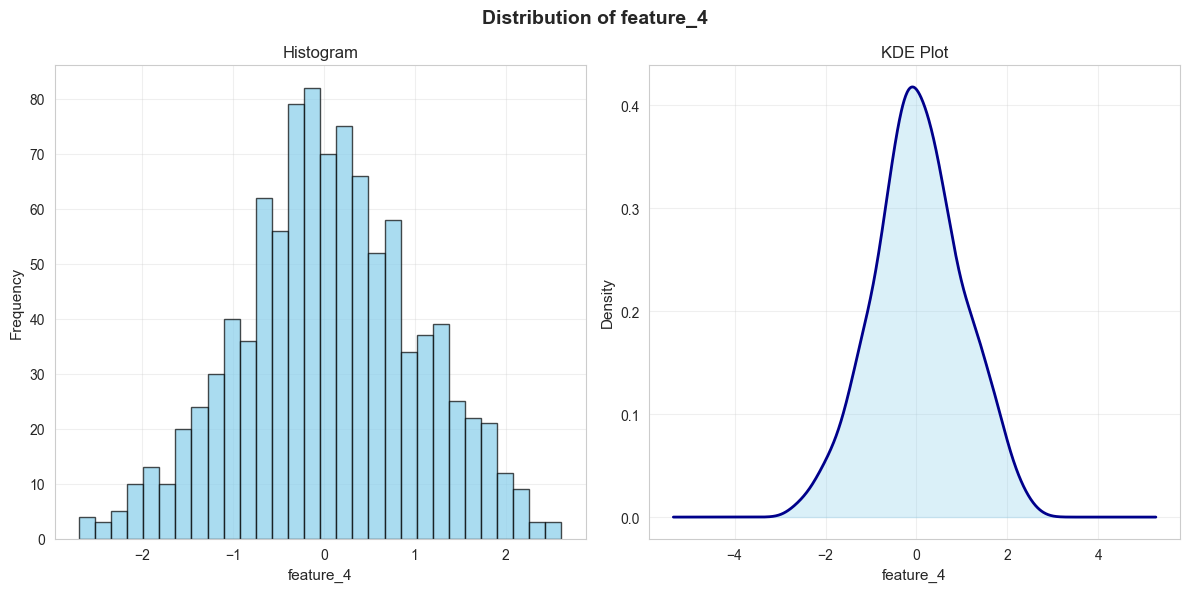

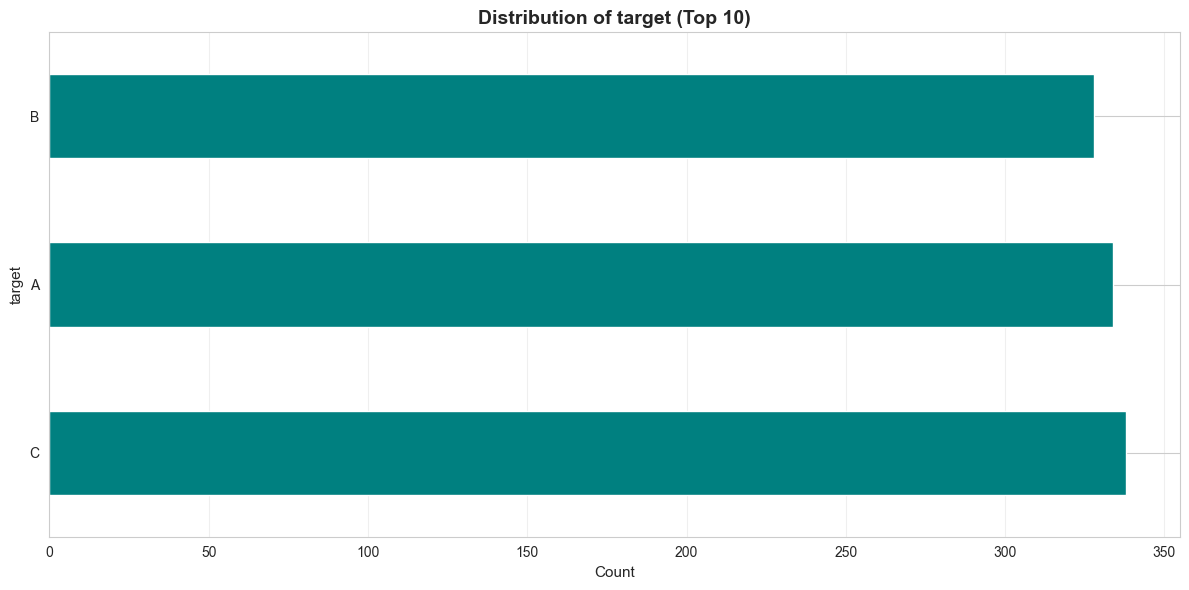

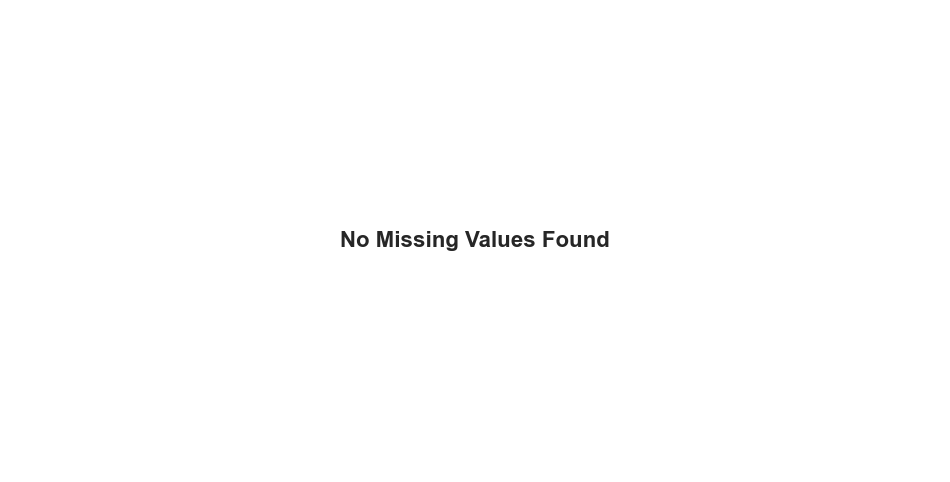

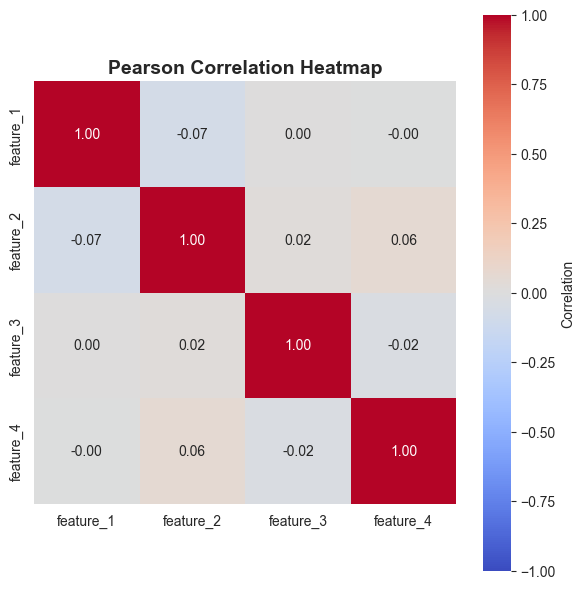

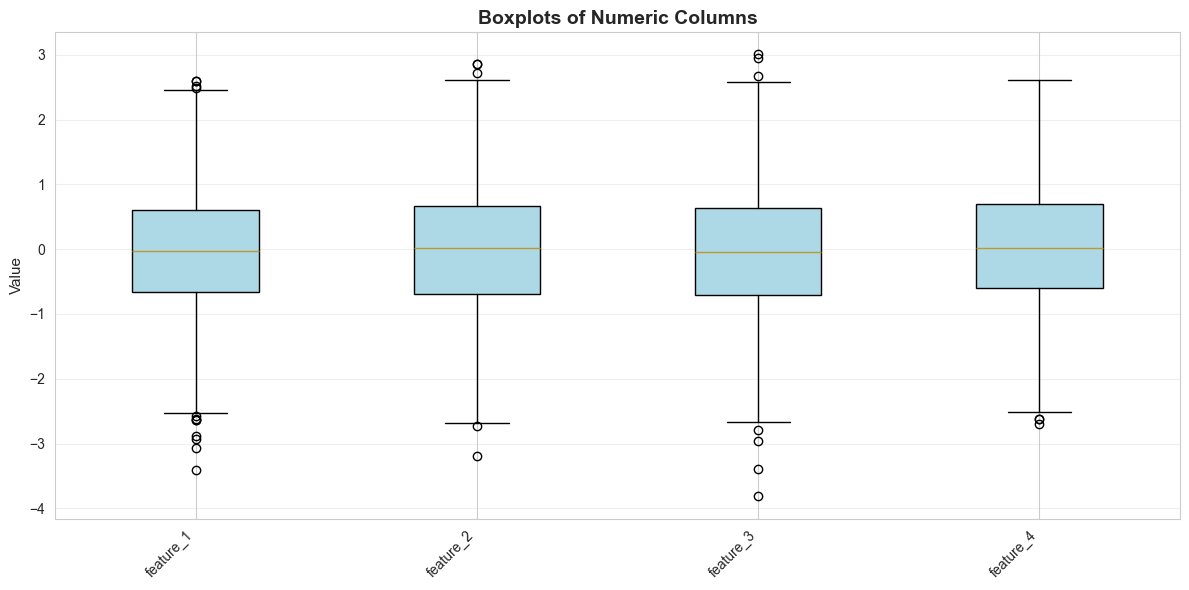

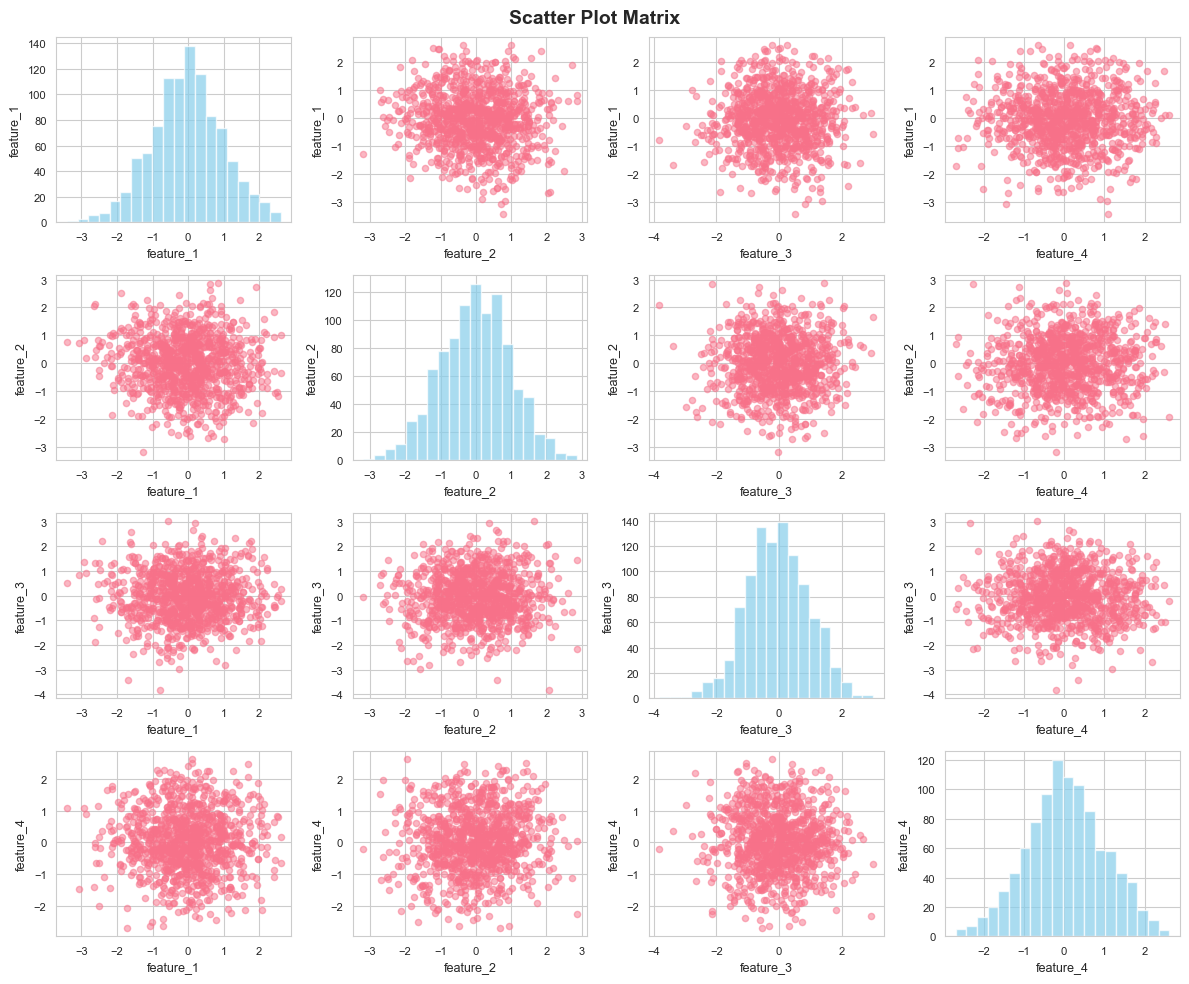

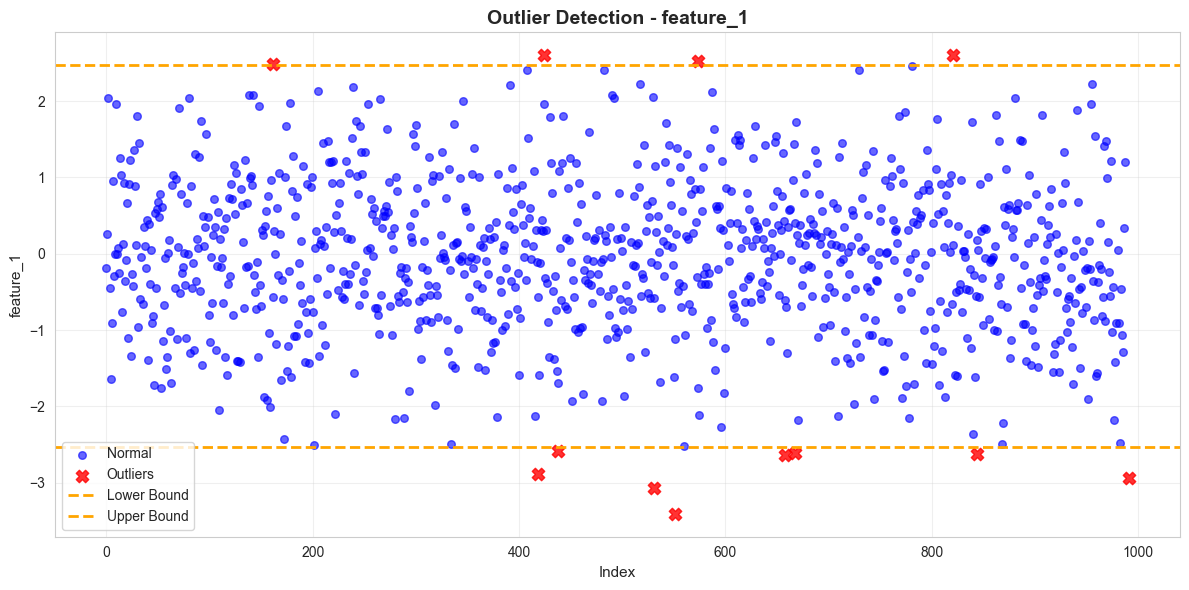

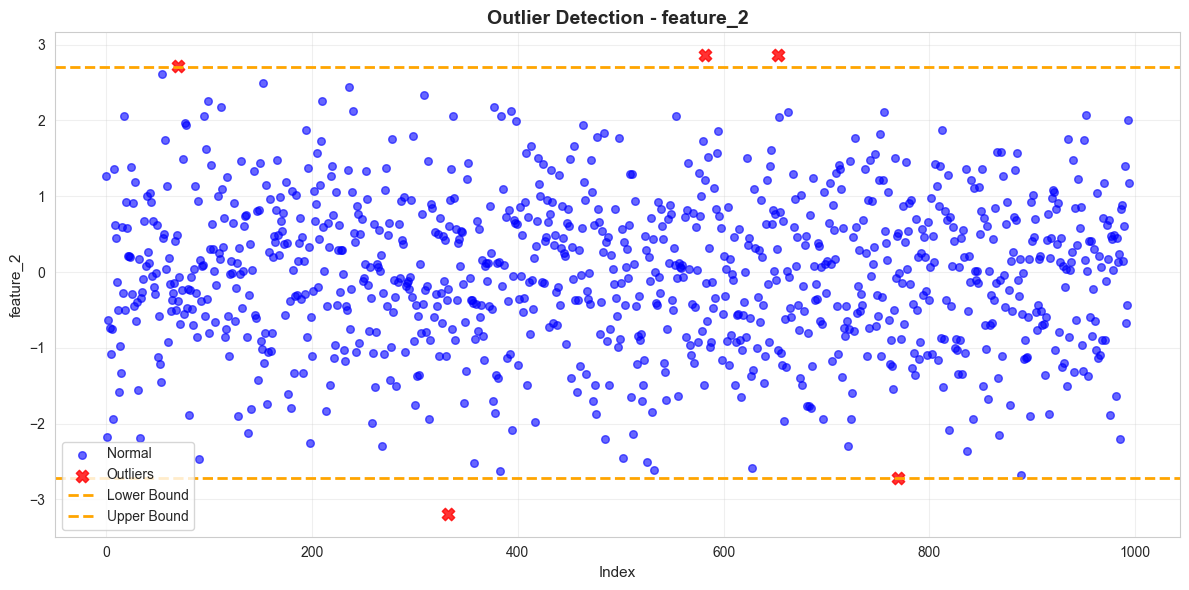

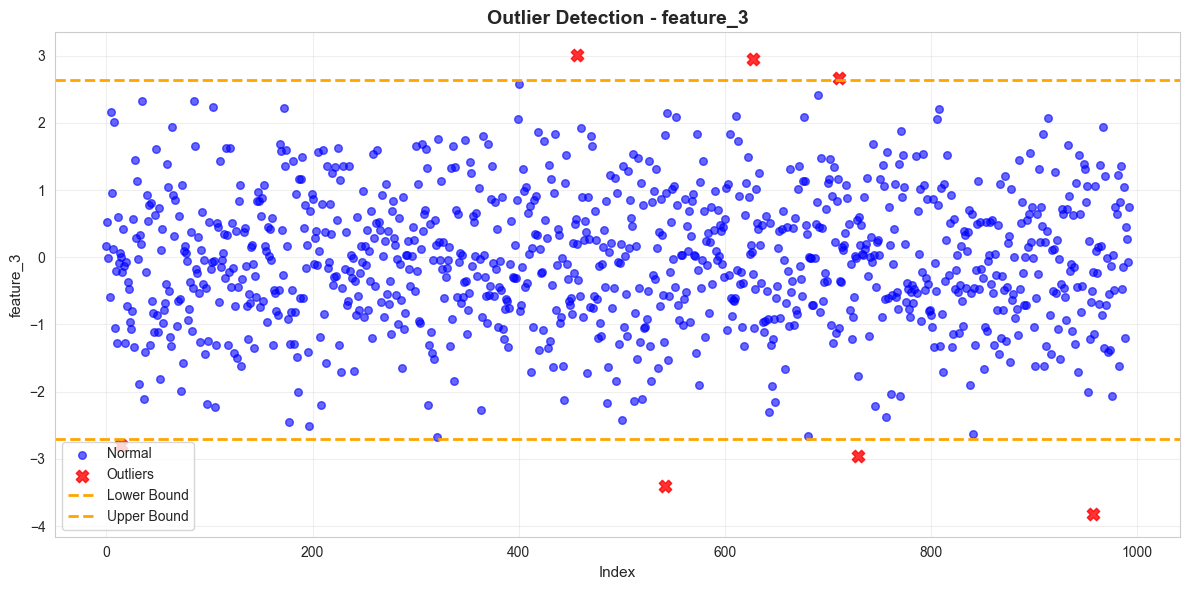

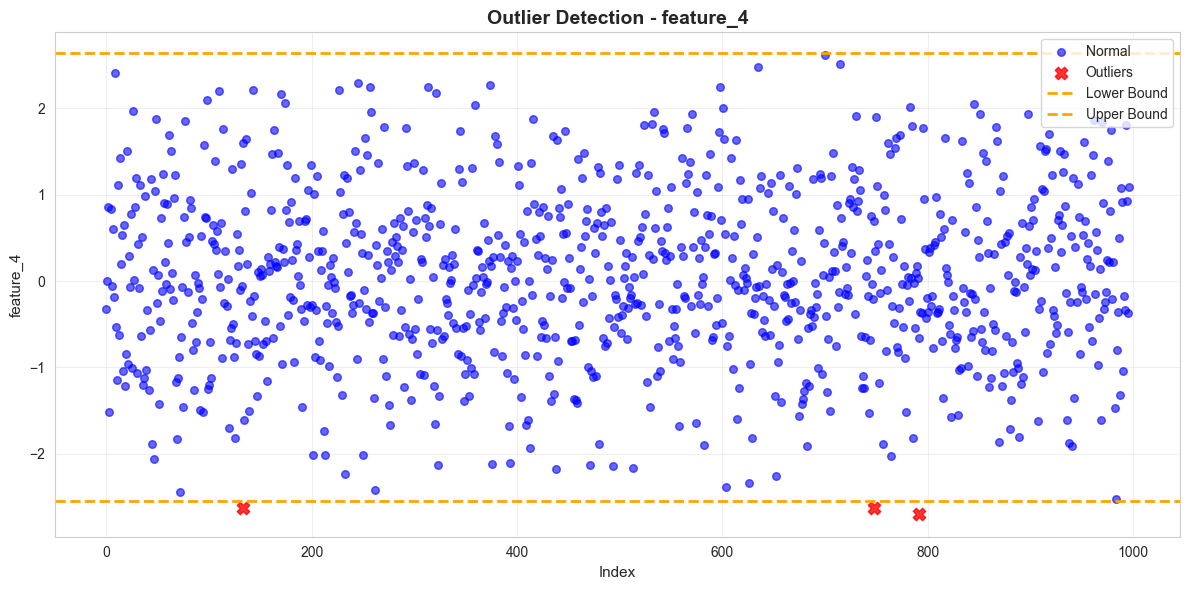

In [8]:
# Create a larger dataset
large_df = pd.DataFrame({
    'feature_1': np.random.randn(10000),
    'feature_2': np.random.randn(10000),
    'feature_3': np.random.randn(10000),
    'feature_4': np.random.randn(10000),
    'target': np.random.choice(['A', 'B', 'C'], 10000),
})

print(f"\n=== Example 4: Batch Sampling ===")
print(f"Large dataset size: {large_df.shape[0]} rows")
print(f"\nRunning analysis on 1000-row sample for speed...\n")

autolyse_batch = Autolyse(
    html=False,
    api_key=GEMINI_KEY,
    random_seed=42,
    batch_size=1000,  # Sample 1000 rows out of 10,000
    enable_statistics=True,
    enable_missing_values=True,
    enable_distributions=True,
    enable_outliers=True,
    enable_correlations=True,
    enable_relationships=True,
    enable_advanced_insights=True
)

results_batch = autolyse_batch.analyse(large_df, show_progress=True)

In [9]:
print(f"\nDataset used for analysis: {autolyse_batch.df.shape[0]} rows")
print(f"Reduction: {(1 - 1000/10000) * 100:.0f}% fewer rows")
print(f"Analysis still comprehensive but 10x faster!")


Dataset used for analysis: 1000 rows
Reduction: 90% fewer rows
Analysis still comprehensive but 10x faster!


## Example 5: Advanced Insights - Multivariate Pattern Detection

Enable advanced analysis to detect complex patterns in 3+ features.


=== Example 5: Advanced Insights (Multivariate Analysis) ===
Detecting feature interactions, clusters, and multivariate patterns...

Starting Autolyse Analysis...
Dataset: 500 rows × 8 columns

1️⃣  Analyzing data structure and types...
2️⃣  Running analyzers (7 enabled)...
3️⃣  Generating visualizations (matplotlib + plotly)...
4️⃣  Generating AI insights...
5️⃣  Preparing output...


# Automated EDA Analysis - Autolyse

## Dataset Summary


**Dataset Shape:** 500 rows × 8 columns

**Column Information:**
- Numeric Columns: 6
- Categorical Columns: 2
- Date Columns: 0
- Missing Values: 0
        

## Column Information

...

## Visualizations

### Distributions

### Missing Values

### Correlation Heatmap

### Boxplots

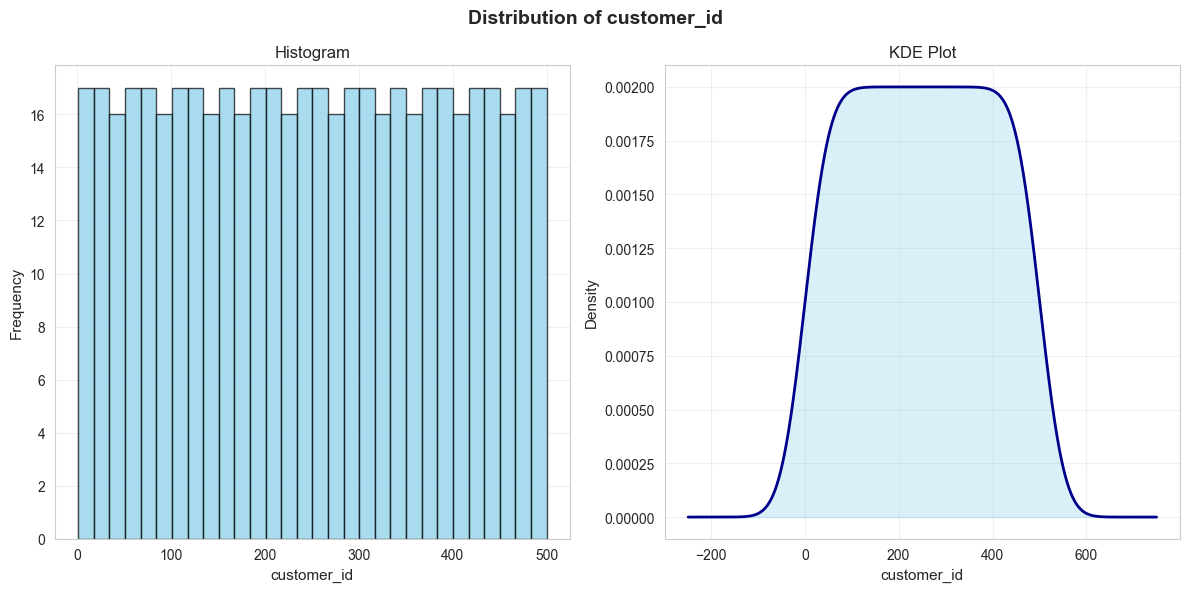

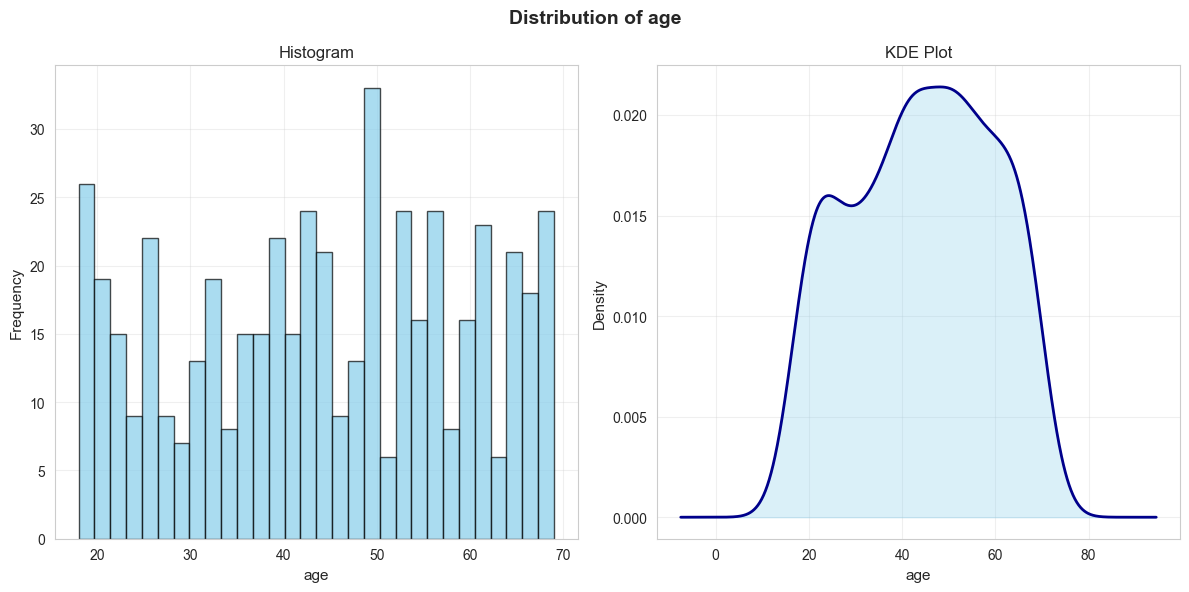

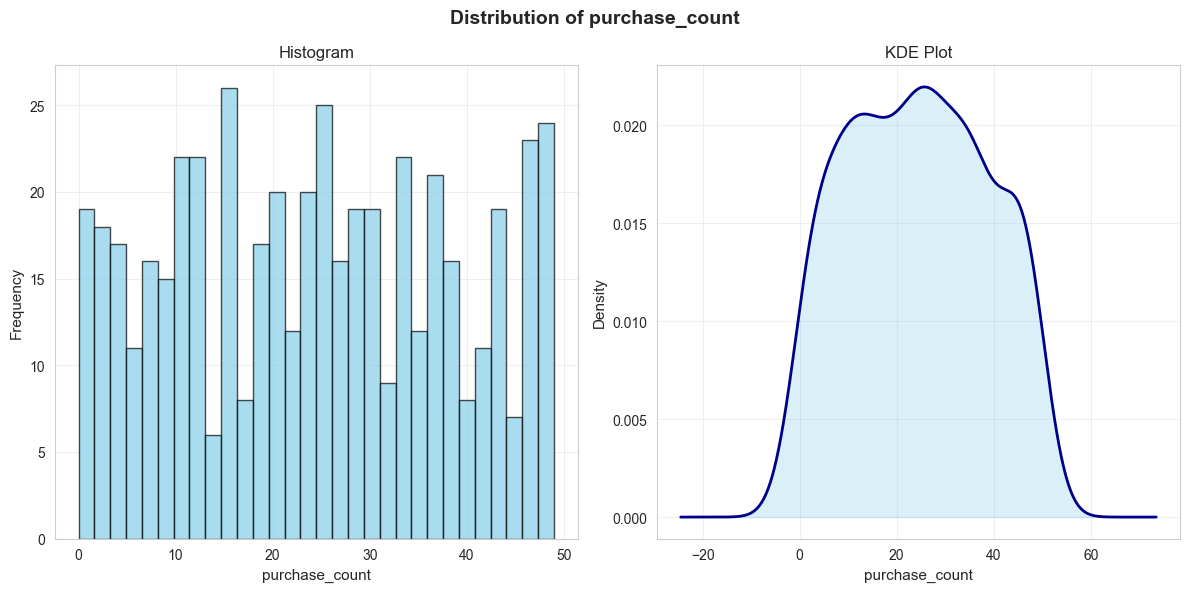

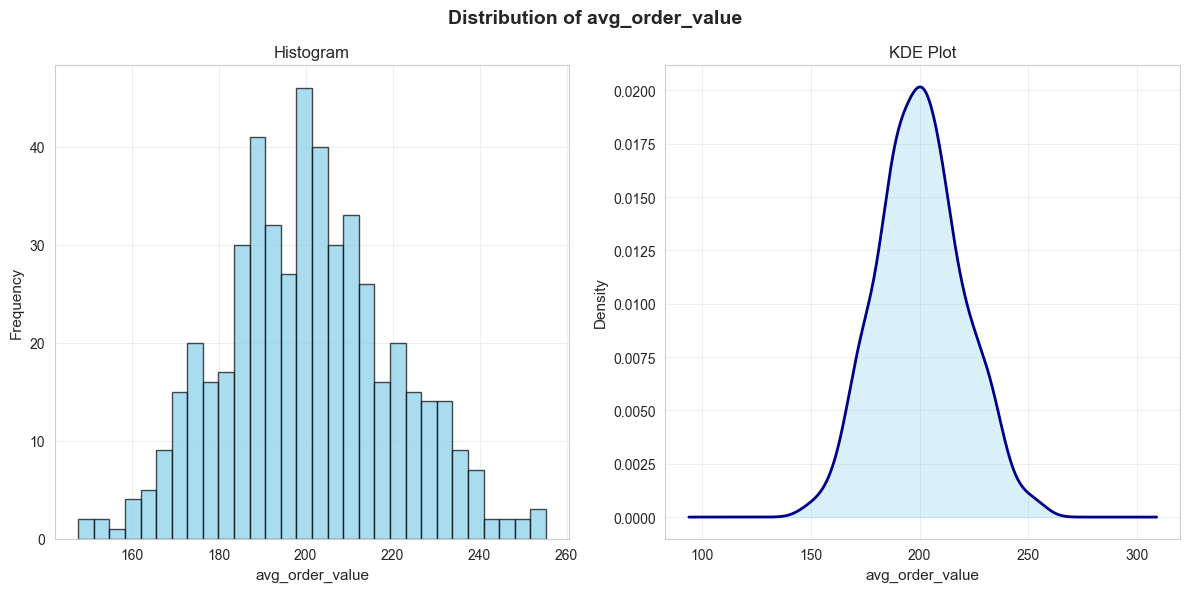

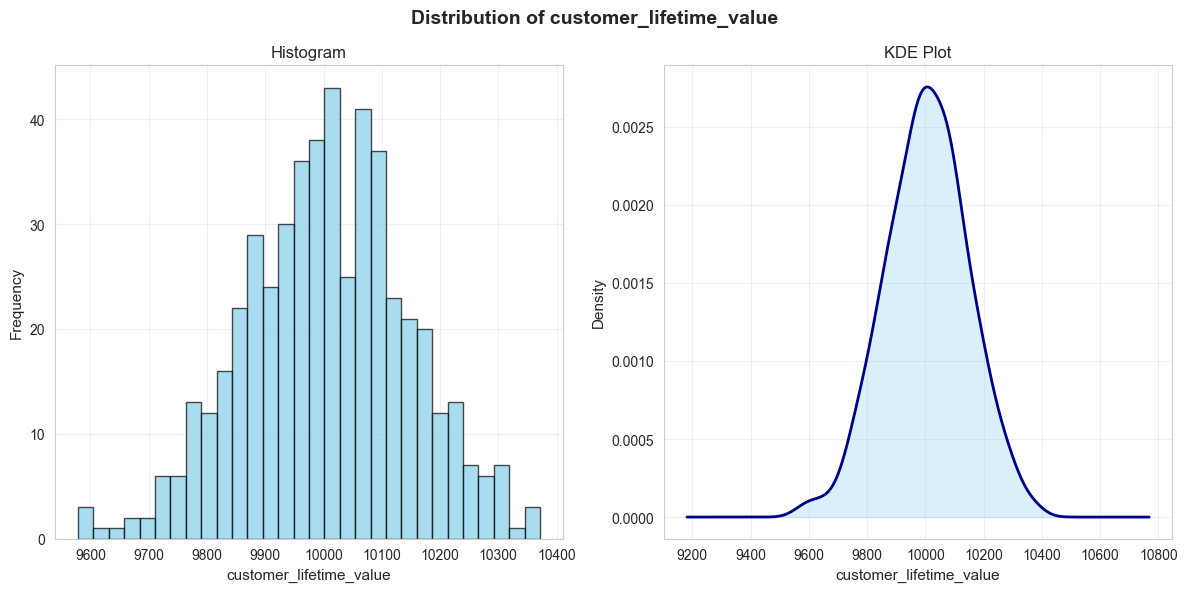

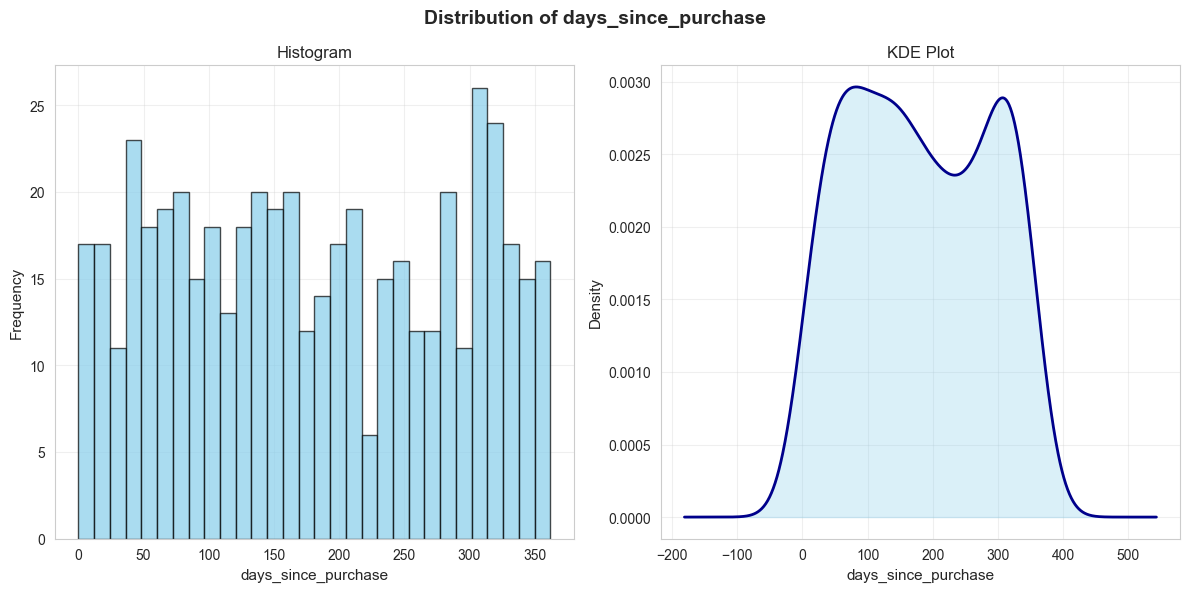

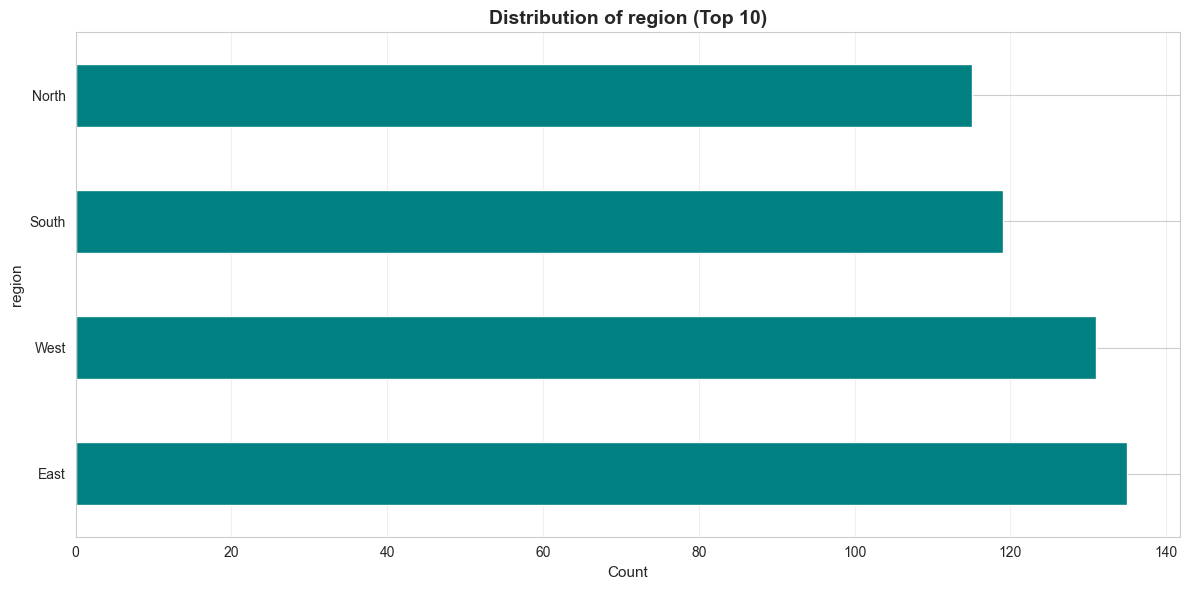

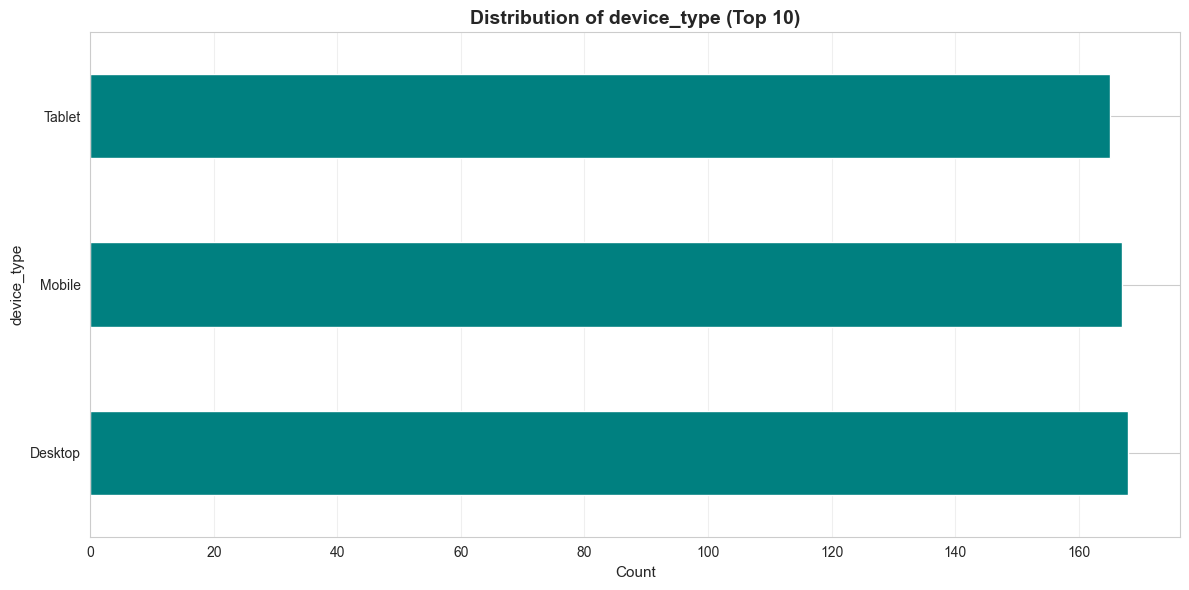

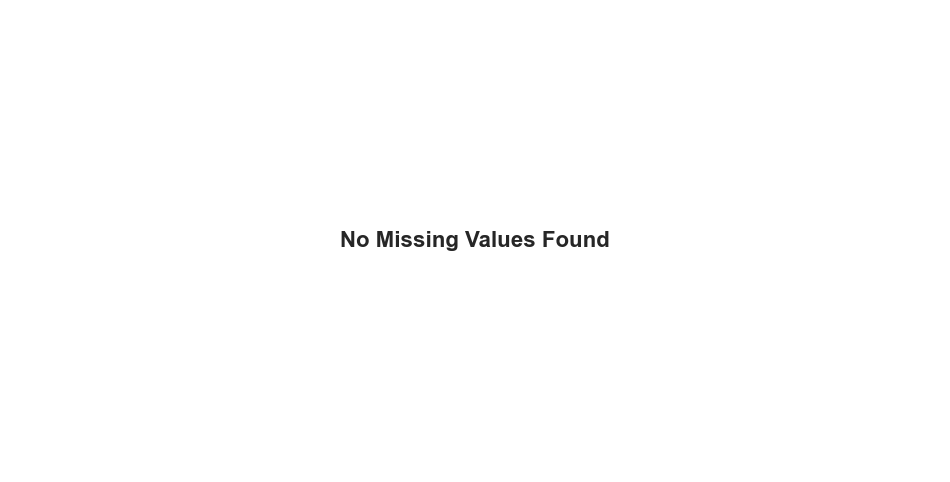

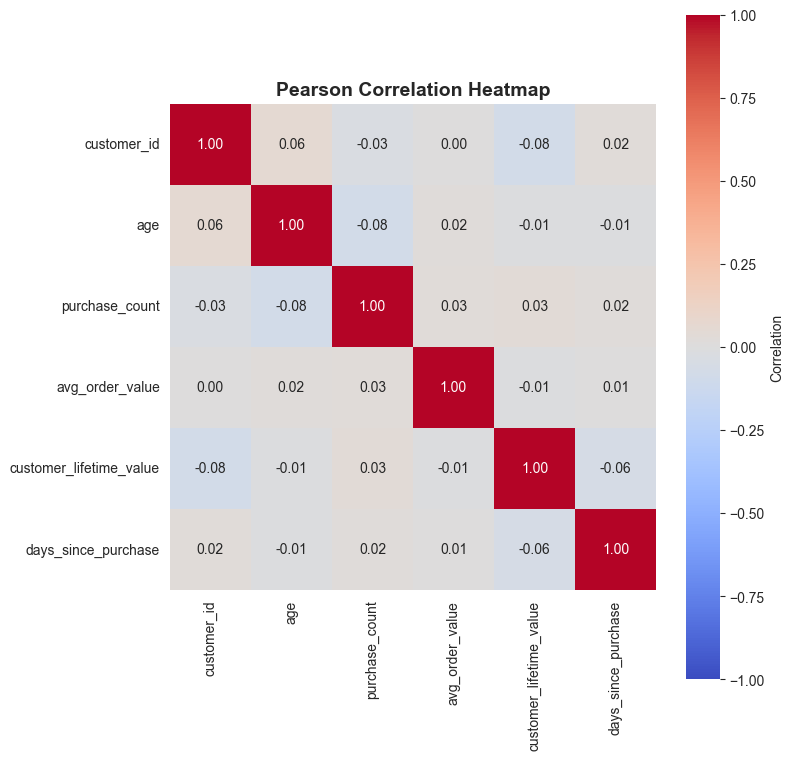

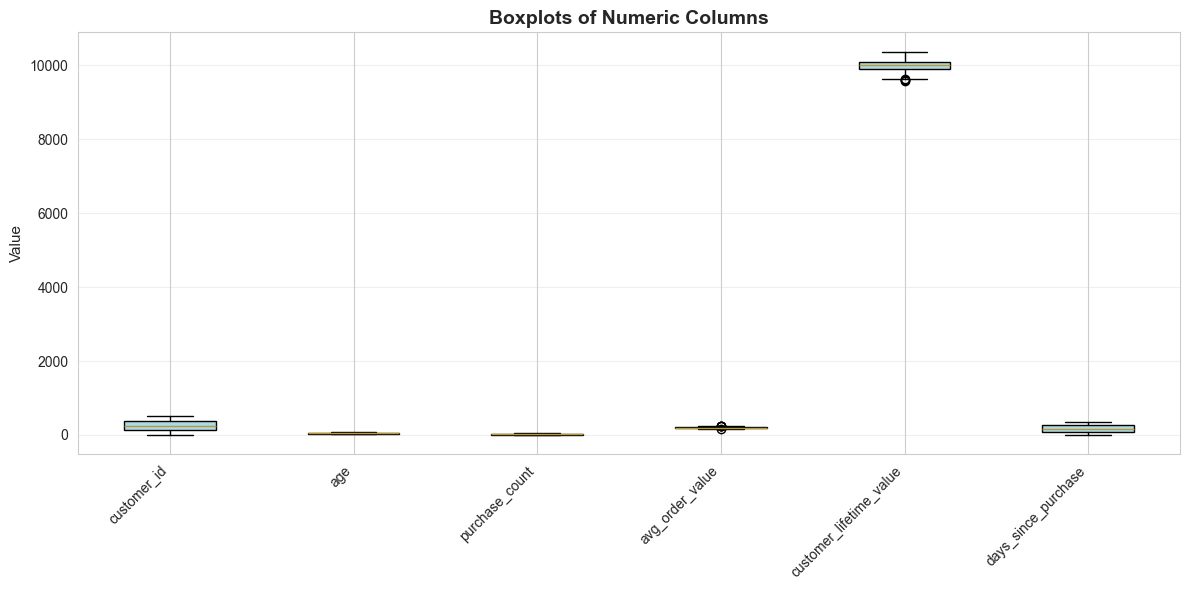

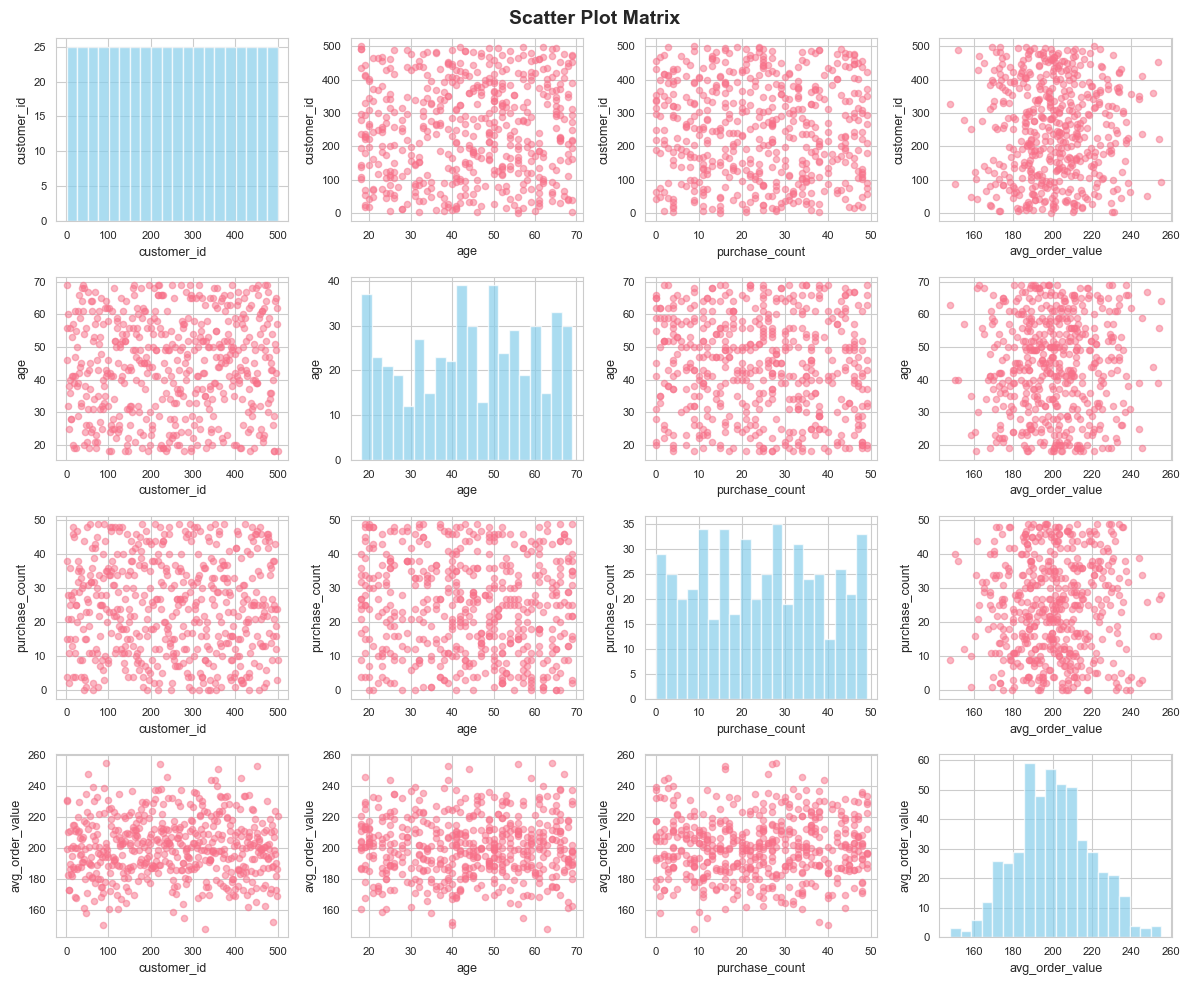

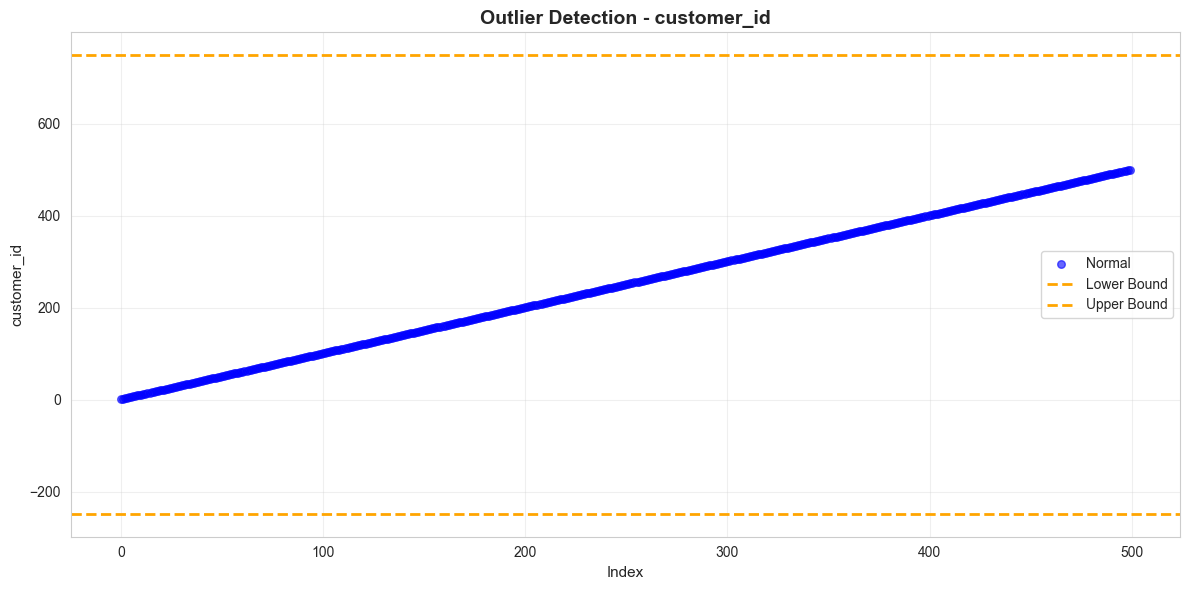

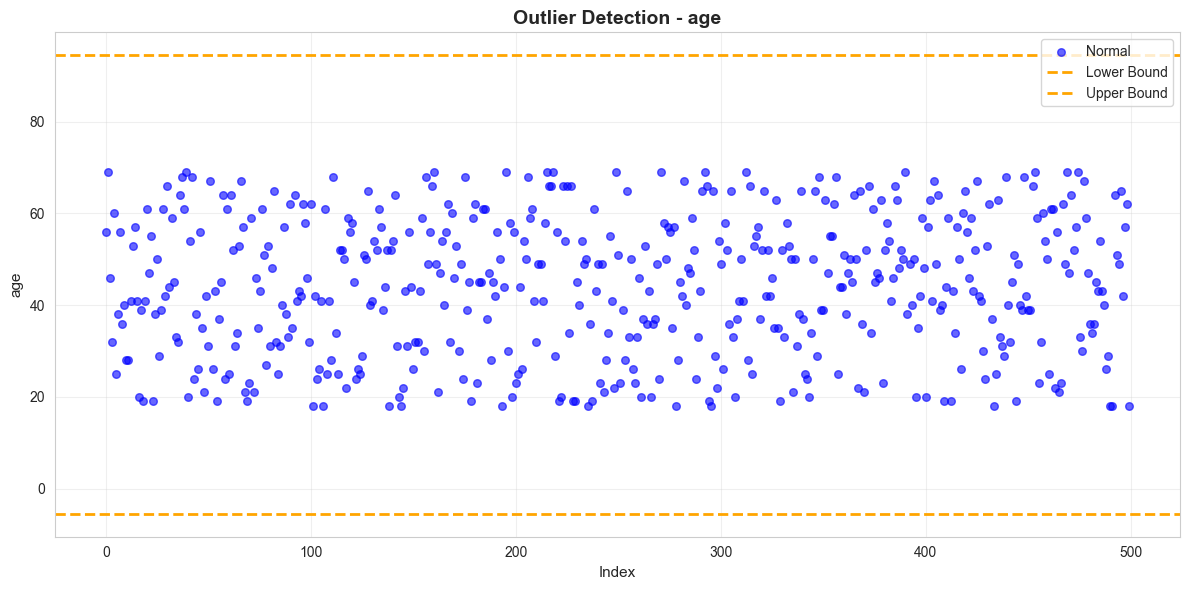

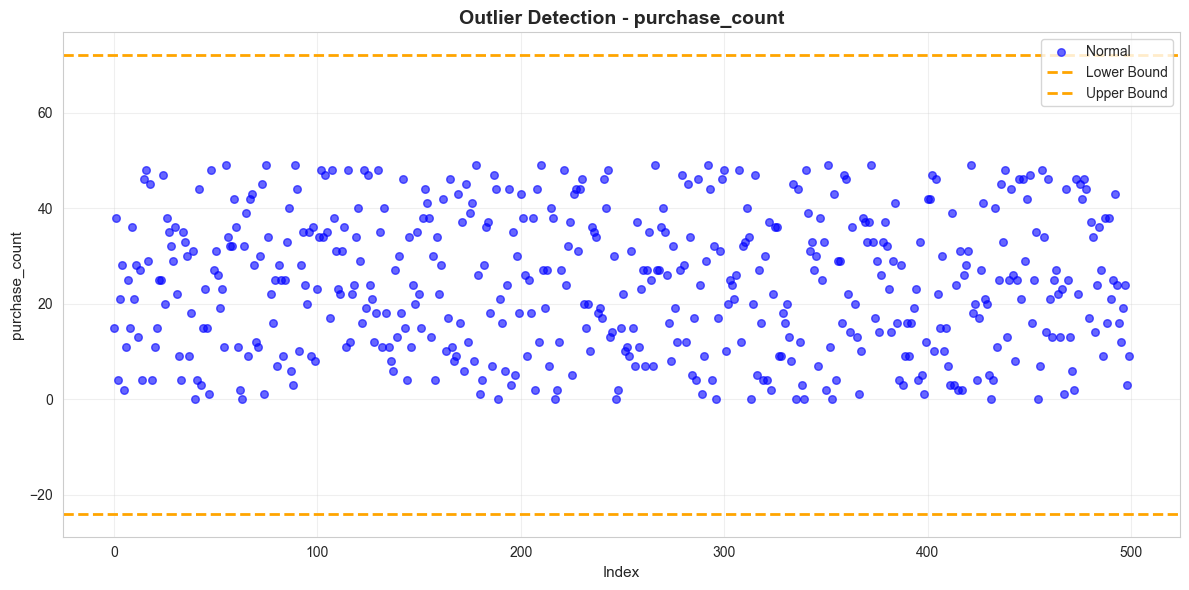

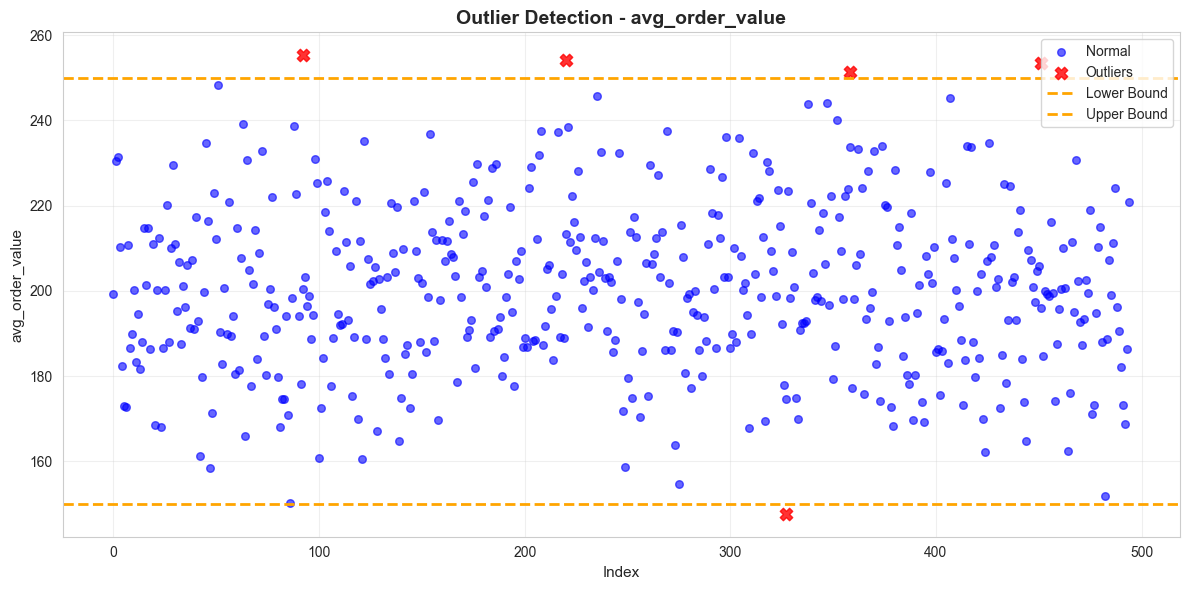

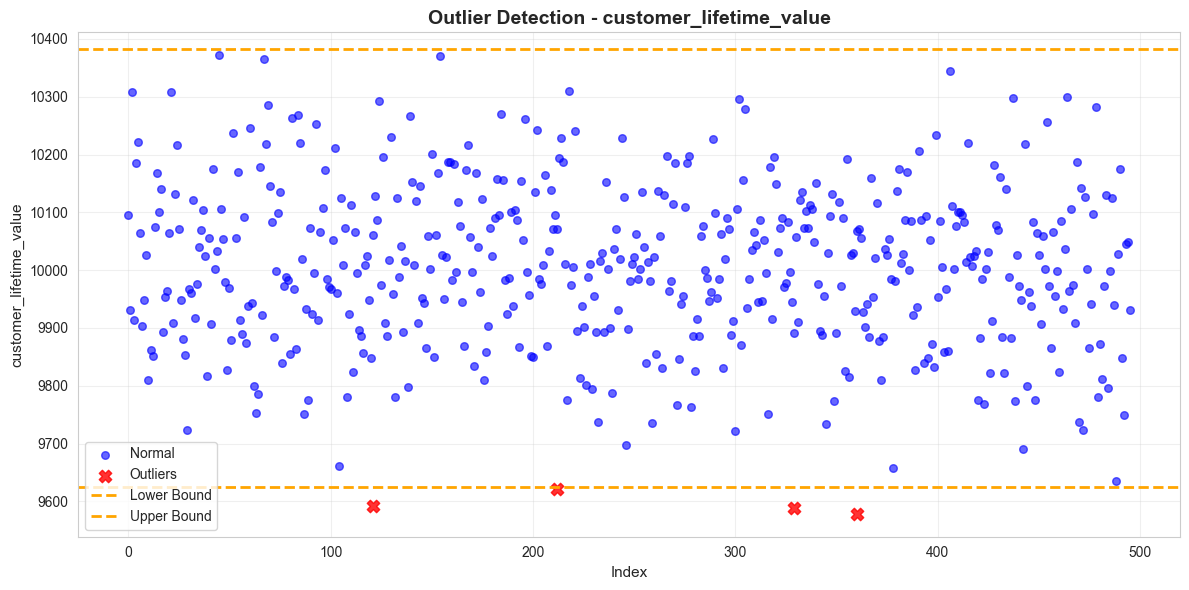

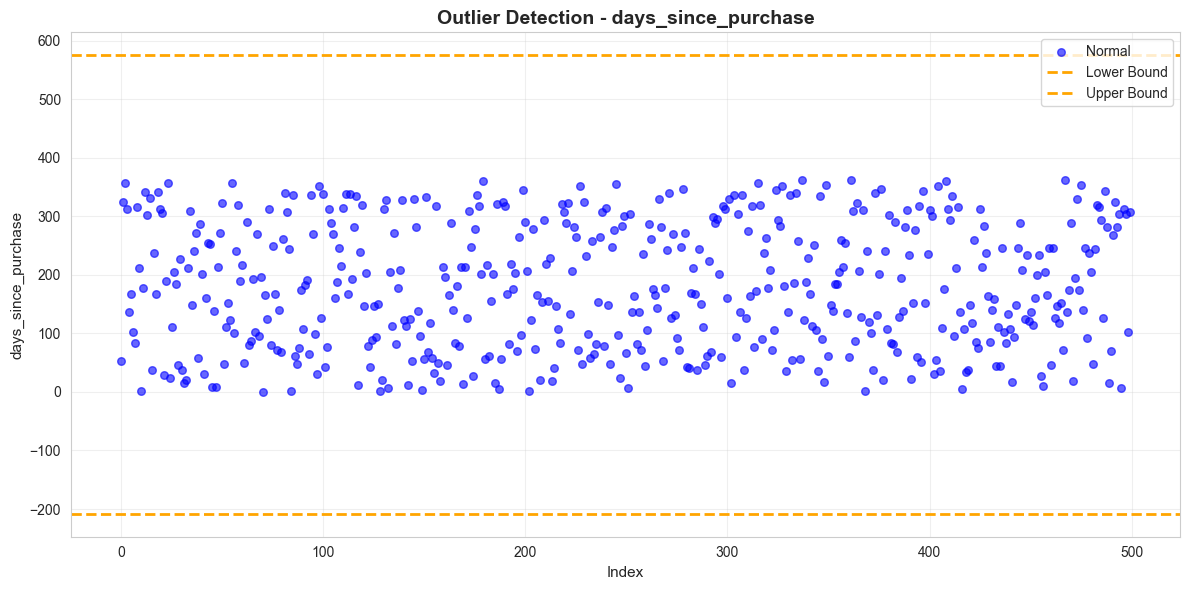

In [2]:
print("\n=== Example 5: Advanced Insights (Multivariate Analysis) ===")
print("Detecting feature interactions, clusters, and multivariate patterns...\n")

autolyse_advanced = Autolyse(
    html=False,
    api_key=GEMINI_KEY,
    random_seed=42,
    enable_advanced_insights=True  # ✓ Enable deep pattern detection
)

results_advanced = autolyse_advanced.analyse(ecommerce_df, show_progress=True)

In [4]:
# Extract advanced insights
advanced_insights = results_advanced.get('advanced_insights', {})

if 'feature_interactions' in advanced_insights:
    interactions = advanced_insights['feature_interactions']
    print(f"\n✓ Feature Interactions Found: {len(interactions)}")
    if interactions:
        print(f"  Top interaction: {interactions[0].get('features', 'N/A')}")
        print(f"  Strength: {interactions[0].get('interaction_strength', 'N/A'):.3f}")

if 'feature_clusters' in advanced_insights:
    clusters = advanced_insights['feature_clusters']
    print(f"\n✓ Feature Clusters Found: {clusters.get('num_clusters', 0)}")
    if 'clusters' in clusters:
        for i, cluster in enumerate(clusters['clusters']):
            print(f"  Cluster {i+1}: {cluster}")

if 'anomaly_patterns' in advanced_insights:
    patterns = advanced_insights['anomaly_patterns']
    print(f"\n✓ Anomaly Patterns Detected: {patterns.get('n_anomalies', 0)}")

if 'temporal_patterns' in advanced_insights:
    temporal = advanced_insights['temporal_patterns']
    print(f"\n✓ Temporal Patterns Detected: {len(temporal)}")


✓ Feature Interactions Found: 3


KeyError: 0

## Example 6: Combined - Full Power with All Features

Use all features together for maximum analysis capability.

In [ ]:
print("\n=== Example 6: Full Power - All Features Combined ===")
print("✓ Feature engineering enabled")
print("✓ Advanced insights enabled") 
print("✓ Full granular control")
print("✓ Random seed for reproducibility")
print("✓ All visualizations enabled\n")

autolyse_full = Autolyse(
    html=True,  # Generate HTML report
    api_key=GEMINI_KEY,
    output_dir="./full_analysis_report",
    random_seed=42,
    # Enable all features
    enable_statistics=True,
    enable_missing_values=True,
    enable_distributions=True,
    enable_outliers=True,
    enable_correlations=True,
    enable_relationships=True,
    enable_advanced_insights=True,
    enable_feature_engineering=True,
    enable_visualizations=True
)

# Run full analysis
full_results = autolyse_full.analyse(ecommerce_df, show_progress=True)

In [ ]:
# Show comprehensive summary
print("\n=== COMPREHENSIVE ANALYSIS SUMMARY ===")
results = autolyse_full.get_analysis_results()

print(f"\nAnalyses completed: {len(results)}")
for analysis_name in results.keys():
    print(f"  ✓ {analysis_name.replace('_', ' ').title()}")

print(f"\nDataset transformation:")
print(f"  Original columns: {ecommerce_df.shape[1]}")
print(f"  Final columns: {autolyse_full.df.shape[1]}")
print(f"  Features created: {autolyse_full.df.shape[1] - ecommerce_df.shape[1]}")

print(f"\nInsights generated: {len(autolyse_full.get_insights())}")
for insight_name in autolyse_full.get_insights().keys():
    print(f"  ✓ {insight_name}")

## Configuration Reference

### Granular Control Flags

| Parameter | Default | Purpose |
|-----------|---------|----------|
| `enable_statistics` | True | Compute mean, std, quartiles, skewness, kurtosis |
| `enable_missing_values` | True | Analyze data quality and missing patterns |
| `enable_distributions` | True | Detect distribution types (normal, uniform, etc.) |
| `enable_outliers` | True | IQR + Isolation Forest outlier detection |
| `enable_correlations` | True | Pearson & Spearman correlation analysis |
| `enable_relationships` | True | Complex relationships between variables |
| `enable_advanced_insights` | True | Multivariate patterns, interactions, clusters |
| `enable_feature_engineering` | False | Auto-create polynomial/interaction/ratio features |
| `enable_visualizations` | True | Generate matplotlib + plotly charts |

### Other Parameters

| Parameter | Default | Purpose |
|-----------|---------|----------|
| `random_seed` | 42 | Fixed seed for reproducible analysis |
| `batch_size` | None | Sample N rows (set to enable sampling) |
| `html` | True | Generate HTML report (False = Jupyter display) |
| `api_key` | None | Gemini API key for AI insights |
| `output_dir` | "./output_reports" | Directory for HTML reports |

### Performance Tips

- **Large datasets**: Use `batch_size=len(df)/10` for 10x speedup
- **Quick iteration**: Disable non-essential analyses with flags
- **Reproducibility**: Set `random_seed=42` (or any fixed value)
- **Feature engineering**: `enable_feature_engineering=True` adds max 20 features
- **Deep analysis**: Enable `enable_advanced_insights=True` for 3+ feature patterns